# Point-Supervised Building Segmentation and the Limits of Self-Training — A Pilot Study

## Week 1

## Installing Library

In [ ]:
!pip install torchgeo

## Basic Setup

In [9]:
import os, sys, glob, json, math, random, time, shutil
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from PIL import Image
import segmentation_models_pytorch as smp

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"torch {torch.__version__} | smp {smp.__version__} | device: {DEVICE}")
assert torch.cuda.is_available(), "Week 1 assumes a GPU — CPU will be ~20x slower."
torch.backends.cudnn.benchmark = True   # speed; run-to-run variance is handled by multi-seed

IMAGENET_MEAN = [0.485, 0.456, 0.406]   # REQUIRED: encoder_weights='imagenet'
IMAGENET_STD  = [0.229, 0.224, 0.225]   # (this was missing before — it handicapped both models)

torch 2.11.0+cu128 | smp 0.5.0 | device: cuda


In [9]:
!mkdir -p ~/.kaggle
!cp kaggle./json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle./json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [15]:
!kaggle datasets download -d balraj98/massachusetts-buildings-dataset -p data/mass_buildings/ --unzip

Dataset URL: https://www.kaggle.com/datasets/balraj98/massachusetts-buildings-dataset
License(s): other
100% 1.49G/1.49G [00:40<00:00, 39.3MB/s]



In [ ]:
import os
os.listdir('data/mass_buildings')

['png', 'label_class_dict.csv', 'tiff', 'metadata.csv']

In [ ]:
print("Inside png:", os.listdir('data/mass_buildings/png'))
example_subfolder = os.listdir('data/mass_buildings/png')[0]
subfolder_path = os.path.join('data/mass_buildings/png', example_subfolder)
if os.path.isdir(subfolder_path):
    print(f"Inside png/{example_subfolder}:", os.listdir(subfolder_path)[:5])

Inside png: ['train', 'train_labels', 'val_labels', 'val', 'test_labels', 'test']
Inside png/train: ['23579065_15.png', '23128960_15.png', '23879095_15.png', '23129170_15.png', '22679020_15.png']


In [16]:
@dataclass
class CFG:
    data_root: str = 'data/mass_buildings/png'
    crop_size: int = 256
    crops_per_tile: int = 16          # 137 tiles x 16 = 2192 crops/epoch (same budget as before)
    p_center: float = 0.5             # prob. of centering a crop on a random click
    n_points: int = 5                 # clicks PER CLASS PER TILE (the honest claim)
    gamma: float = 2.0
    alpha: float = 0.5                # neutral: point sets are class-balanced (ablate in Week 2)
    epochs: int = 60                  # if the supervised val curve is still rising, raise to 100
    batch_size: int = 16
    lr: float = 3e-4
    weight_decay: float = 1e-4
    warmup_epochs: int = 3
    seeds: tuple = (0, 1, 2)          # each seed = one simulated annotator
    num_workers: int = 2              # set 0 if your environment struggles with workers
    run_dir: str = '/content/drive/MyDrive/wsss_runs'

SPLIT_OFFSET = {'train': 0, 'val': 500_000, 'test': 900_000}  # keeps point seeds disjoint per split
EXPECTED = {'train': 137, 'val': 4, 'test': 10}

In [17]:
root = Path(CFG.run_dir)
checks = ['week1_summary.json', 'sup_bce_dice_seed0', 'pfce_n5_seed0',
          'w2_cache', 'annotations']
missing = [c for c in checks if not (root / c).exists()]
print('run_dir ->', root)
print('MISSING:', missing if missing else 'nothing — everything is in place ✓')

run_dir -> /content/drive/MyDrive/wsss_runs
MISSING: nothing — everything is in place ✓


### Helper Functions

In [18]:
def set_global_seed(seed: int):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

In [19]:
ROOT = Path(CFG.data_root)

def verify_split(root: Path, split: str, expected: int):
    imgs  = sorted((root / split).glob('*.png'))
    masks = sorted((root / f'{split}_labels').glob('*.png'))
    ok = (len(imgs) == expected and len(masks) == expected
          and [p.stem for p in imgs] == [p.stem for p in masks])
    return ok

if all(verify_split(ROOT, s, n) for s, n in EXPECTED.items()):
    print("Local dataset verified: 137 train / 4 val / 10 test.")
else:
    print("Local data incomplete — attempting TorchGeo download…")
    from torchgeo.datasets import MassachusettsBuildings
    for split in ('train', 'val', 'test'):
        MassachusettsBuildings(root='data/torchgeo', split=split, download=True)
    # find the extracted 'png' folder containing train/train_labels
    cand = [d for d in Path('data/torchgeo').rglob('*')
            if d.is_dir() and (d / 'train').exists() and (d / 'train_labels').exists()]
    if not cand:
        raise RuntimeError("Download failed. Get the dataset manually (Kaggle: 'Massachusetts "
                           "Buildings Dataset') and place train/ train_labels/ val/ val_labels/ "
                           "test/ test_labels/ under data/mass_buildings/png/.")
    ROOT.parent.mkdir(parents=True, exist_ok=True)
    try:
        ROOT.symlink_to(cand[0].resolve())
    except OSError:
        shutil.copytree(cand[0], ROOT, dirs_exist_ok=True)
    assert all(verify_split(ROOT, s, n) for s, n in EXPECTED.items())
    print("Dataset ready.")

Local dataset verified: 137 train / 4 val / 10 test.


In [20]:
class TileStore:
    """Full tiles cached once. Images uint8 (3,H,W); masks bool (H,W). Dense masks live ONLY here."""
    def __init__(self, root: Path, split: str):
        self.split = split
        img_paths  = sorted((root / split).glob('*.png'))
        mask_paths = sorted((root / f'{split}_labels').glob('*.png'))
        assert [p.stem for p in img_paths] == [p.stem for p in mask_paths]
        self.ids, self.images, self.masks = [], [], []
        for ip, mp in zip(img_paths, mask_paths):
            img = np.asarray(Image.open(ip).convert('RGB'))
            msk = np.asarray(Image.open(mp).convert('L'))
            self.ids.append(ip.stem)
            self.images.append(torch.from_numpy(img.copy()).permute(2, 0, 1).contiguous())
            self.masks.append(torch.from_numpy(msk > 127))
        shapes = {tuple(m.shape) for m in self.masks}
        assert len(shapes) == 1, f"Inconsistent tile shapes in {split}: {shapes}"
        self.tile_shape = shapes.pop()
    def __len__(self) -> int:
        return len(self.images)

    def __getitem__(self, idx: int):
        return {'image': self.images[idx], 'mask': self.masks[idx], 'id': self.ids[idx]}


store_train, store_val, store_test = (TileStore(ROOT, s) for s in ('train', 'val', 'test'))
print(f"tile shape: {store_train.tile_shape}")
for s in ('train', 'val', 'test'):
    st = {'train': store_train, 'val': store_val, 'test': store_test}[s]
    fg = [m.float().mean().item() for m in st.masks]
    print(f"{s:5s}: {len(st.ids):3d} tiles | fg fraction mean {np.mean(fg):.3f} "
          f"(min {np.min(fg):.3f}, max {np.max(fg):.3f})")

tile shape: (1500, 1500)
train: 137 tiles | fg fraction mean 0.132 (min 0.031, max 0.306)
val  :   4 tiles | fg fraction mean 0.109 (min 0.060, max 0.151)
test :  10 tiles | fg fraction mean 0.186 (min 0.088, max 0.357)


In [21]:
def sample_tile_points(mask: torch.Tensor, n_points: int, tile_seed: int, bg_margin: int = 0):
    """mask (H,W) bool -> (H,W) float32 with {1=fg click, 0=bg click, -1=none}.
    Draw order fixed (fg then bg) so that the same seed yields NESTED budgets across
    n_points: the N=10 clicks contain the N=5 clicks (incremental annotation)."""
    g = torch.Generator().manual_seed(tile_seed)
    out = torch.full(mask.shape, -1.0, dtype=torch.float32)

    fg = torch.nonzero(mask)
    if fg.shape[0] >= n_points:
        sel = fg[torch.randperm(fg.shape[0], generator=g)[:n_points]]
    elif fg.shape[0] > 0:
        sel = fg[torch.randint(0, fg.shape[0], (n_points,), generator=g)]
    else:
        sel = torch.empty(0, 2, dtype=torch.long)
    out[sel[:, 0], sel[:, 1]] = 1.0

    bg_ok = ~mask
    if bg_margin > 0:  # optional: annotators avoid ambiguous boundary pixels (ablate later)
        dil = F.max_pool2d(mask[None, None].float(), 2 * bg_margin + 1, 1, padding=bg_margin)[0, 0] > 0
        bg_ok = bg_ok & ~dil
    bg = torch.nonzero(bg_ok)
    sel = bg[torch.randperm(bg.shape[0], generator=g)[:n_points]]
    out[sel[:, 0], sel[:, 1]] = 0.0
    return out

def make_point_maps(store, n_points, rep, split_offset, bg_margin=0):
    """rep = simulated annotator index (one per experimental seed)."""
    return [sample_tile_points(store.masks[i], n_points, split_offset + 1000 * rep + i, bg_margin)
            for i in range(len(store))]

def save_manifest(path, store, point_maps, n_points, rep):
    """The auditable 'annotation file' — proof of the exact label budget used."""
    data = {'dataset': 'massachusetts_buildings', 'split': store.split,
            'n_points_per_class': n_points, 'annotator_rep': rep, 'tiles': {}}
    for i, tid in enumerate(store.ids):
        data['tiles'][tid] = {'fg': torch.nonzero(point_maps[i] == 1.0).tolist(),
                              'bg': torch.nonzero(point_maps[i] == 0.0).tolist()}
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    json.dump(data, open(path, 'w'))
    print(f"manifest: {path} ({os.path.getsize(path)/1024:.1f} KB)")

In [ ]:
demo = make_point_maps(store_train, CFG.n_points, rep=0, split_offset=SPLIT_OFFSET['train'])

In [ ]:
# 1) counts
for i in (0, 25, 70, 136):
    print(f"tile {store_train.ids[i]}: fg={int((demo[i]==1).sum())}, bg={int((demo[i]==0).sum())}")

# 2) correctness — every fg click is on a building, every bg click is not
for i in range(len(store_train)):
    assert store_train.masks[i][demo[i] == 1.0].all()
    assert (~store_train.masks[i][demo[i] == 0.0]).all()

# 3) determinism — same seeds => identical annotation
demo2 = make_point_maps(store_train, CFG.n_points, rep=0, split_offset=SPLIT_OFFSET['train'])
assert all(torch.equal(a, b) for a, b in zip(demo, demo2))

# 4) nested budgets — N=10 strictly contains N=5
d10 = make_point_maps(store_train, 10, rep=0, split_offset=SPLIT_OFFSET['train'])
for i in (0, 1, 2):
    set5  = set(map(tuple, torch.nonzero(demo[i] == 1.0).tolist()))
    set10 = set(map(tuple, torch.nonzero(d10[i] == 1.0).tolist()))
    assert set5 <= set10

save_manifest(f'annotations/train_n{CFG.n_points}_rep0.json', store_train, demo, CFG.n_points, 0)
print("All point-protocol checks passed.")

tile 22678915_15: fg=5, bg=5
tile 22979005_15: fg=5, bg=5
tile 23428975_15: fg=5, bg=5
tile 24479005_15: fg=5, bg=5
manifest: annotations/train_n5_rep0.json (21.2 KB)
All point-protocol checks passed.


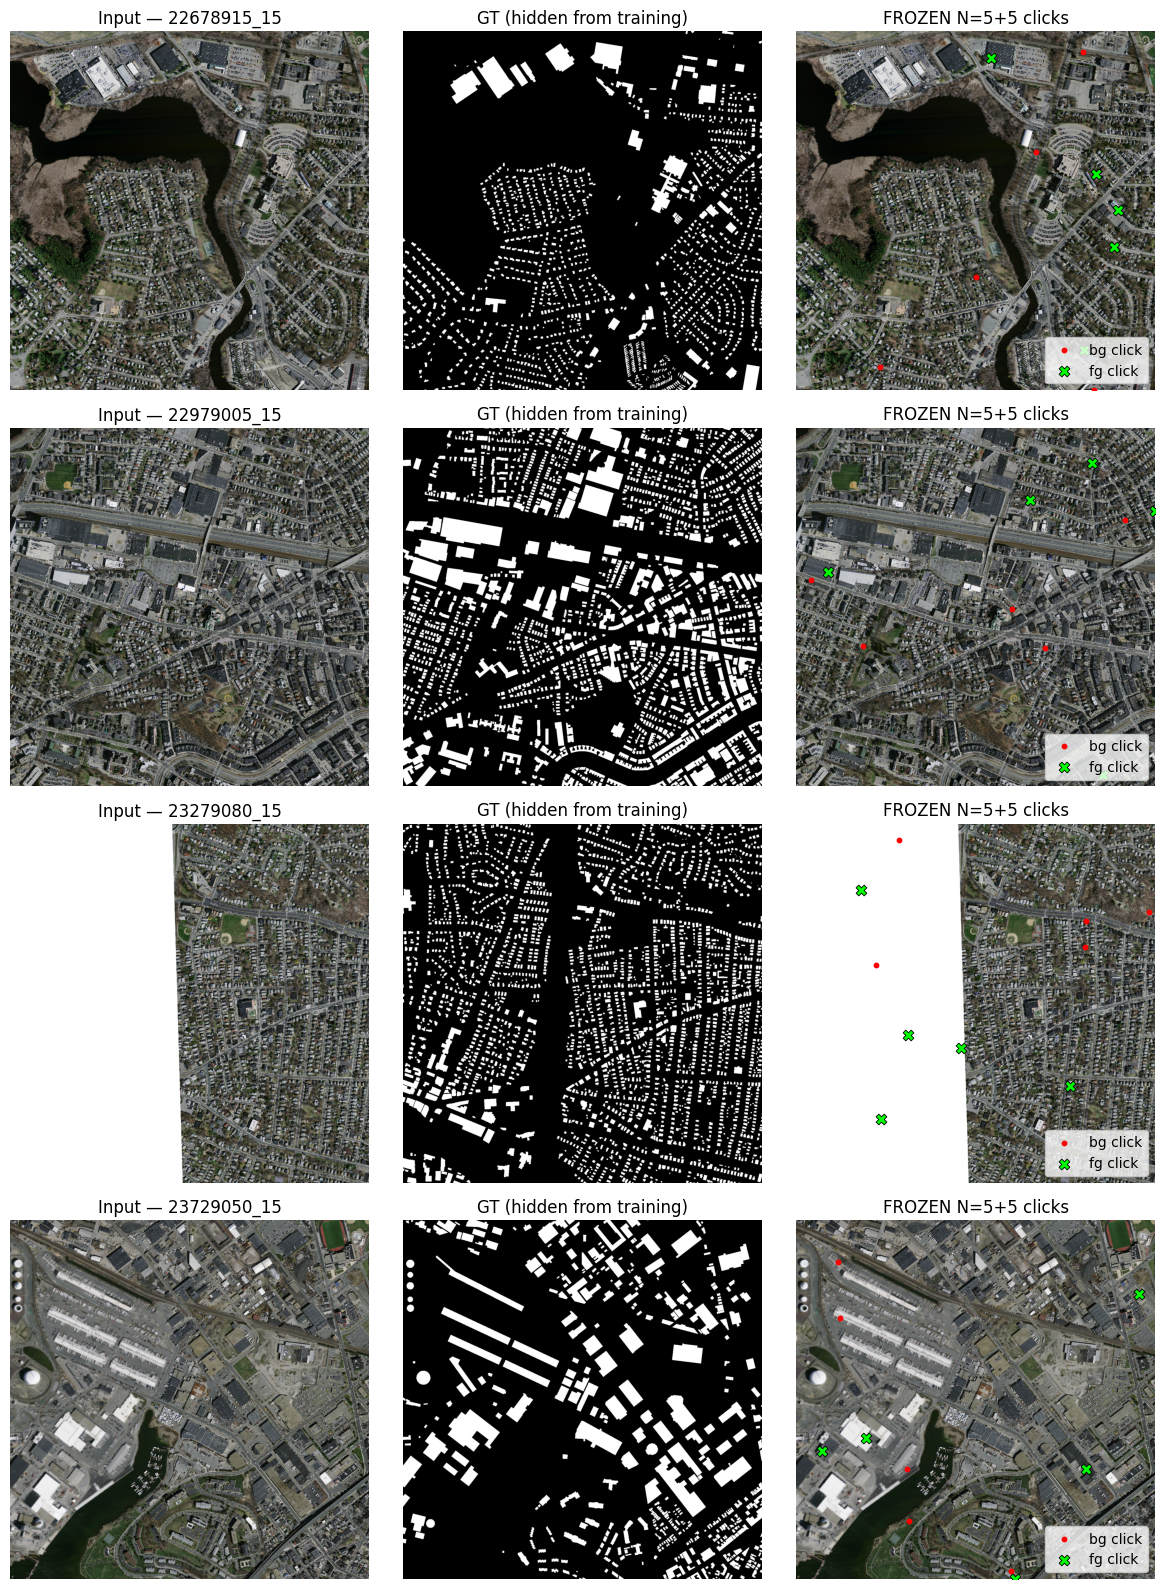

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
for row, t in enumerate((0, 25, 60, 100)):
    img = store_train.images[t].permute(1, 2, 0).numpy()
    axes[row, 0].imshow(img); axes[row, 0].set_title(f"Input — {store_train.ids[t]}")
    axes[row, 1].imshow(store_train.masks[t].numpy(), cmap='gray'); axes[row, 1].set_title("GT (hidden from training)")
    fg = torch.nonzero(demo[t] == 1.0); bg = torch.nonzero(demo[t] == 0.0)
    axes[row, 2].imshow(img)
    axes[row, 2].scatter(bg[:, 1], bg[:, 0], s=10, c='red', marker='o', label='bg click')
    axes[row, 2].scatter(fg[:, 1], fg[:, 0], s=60, c='lime', marker='X',
                         edgecolors='black', linewidths=0.6, label='fg click')
    axes[row, 2].set_title(f"FROZEN N={CFG.n_points}+{CFG.n_points} clicks"); axes[row, 2].legend(loc='lower right')
for ax in axes.flat: ax.axis('off')
plt.tight_layout(); plt.show()

In [22]:
def geom_aug(img: torch.Tensor, maps: List[torch.Tensor]):
    """hflip / vflip / rot90 applied identically to image and every label map.
    Uses global torch RNG — DataLoader seeds workers deterministically, so runs are
    reproducible as long as num_workers stays fixed across compared runs."""
    if torch.rand(()).item() < 0.5:
        img = torch.flip(img, dims=[-1]); maps = [torch.flip(m, dims=[-1]) for m in maps]
    if torch.rand(()).item() < 0.5:
        img = torch.flip(img, dims=[-2]); maps = [torch.flip(m, dims=[-2]) for m in maps]
    k = torch.randint(0, 4, (1,)).item()
    if k:
        img = torch.rot90(img, k, dims=(-2, -1)); maps = [torch.rot90(m, k, dims=(-2, -1)) for m in maps]
    return img, maps

In [23]:
class WeakCropDataset(Dataset):
    """LEAK-PROOF BY CONSTRUCTION: receives images + frozen point maps ONLY.
    Dense ground truth is never passed in, so no training code can touch it."""
    def __init__(self, images, point_maps, crop_size=CFG.crop_size,
                 crops_per_tile=CFG.crops_per_tile, p_center=CFG.p_center):
        self.images, self.points = images, point_maps
        self.crop_size, self.crops_per_tile, self.p_center = crop_size, crops_per_tile, p_center
        self.clicks = [torch.nonzero(p != -1.0) for p in point_maps]   # precomputed once

    def __len__(self): return len(self.images) * self.crops_per_tile

    def _origin(self, t: int):
        H, W = self.points[t].shape; cs = self.crop_size
        cl = self.clicks[t]
        if cl.numel() and torch.rand(()).item() < self.p_center:      # click-biased crop
            r, c = cl[torch.randint(0, cl.shape[0], (1,)).item()].tolist()
            j = cs // 4
            top  = int(min(max(r - cs // 2 + torch.randint(-j, j + 1, (1,)).item(), 0), H - cs))
            left = int(min(max(c - cs // 2 + torch.randint(-j, j + 1, (1,)).item(), 0), W - cs))
        else:                                                          # uniform crop
            top  = torch.randint(0, H - cs + 1, (1,)).item()
            left = torch.randint(0, W - cs + 1, (1,)).item()
        return top, left

    def __getitem__(self, idx):
        t = idx // self.crops_per_tile
        top, left = self._origin(t); cs = self.crop_size
        img = self.images[t][:, top:top + cs, left:left + cs]
        pts = self.points[t][top:top + cs, left:left + cs]
        img, [pts] = geom_aug(img, [pts])
        img = TF.normalize(img.float() / 255.0, IMAGENET_MEAN, IMAGENET_STD)
        return {'image': img, 'points': pts.unsqueeze(0).float()}      # (1,H,W), values {-1,0,1}


class SupCropDataset(Dataset):
    """Fully supervised — dense masks are legitimately available here."""
    def __init__(self, images, masks, crop_size=CFG.crop_size, crops_per_tile=CFG.crops_per_tile):
        self.images, self.masks = images, masks
        self.crop_size, self.crops_per_tile = crop_size, crops_per_tile

    def __len__(self): return len(self.images) * self.crops_per_tile

    def __getitem__(self, idx):
        t = idx // self.crops_per_tile; cs = self.crop_size
        H, W = self.masks[t].shape
        top  = torch.randint(0, H - cs + 1, (1,)).item()
        left = torch.randint(0, W - cs + 1, (1,)).item()
        img = self.images[t][:, top:top + cs, left:left + cs]
        msk = self.masks[t][top:top + cs, left:left + cs].float()
        img, [msk] = geom_aug(img, [msk])
        img = TF.normalize(img.float() / 255.0, IMAGENET_MEAN, IMAGENET_STD)
        return {'image': img, 'mask': msk.unsqueeze(0)}

In [ ]:
weak_ds = WeakCropDataset(store_train.images, demo)

In [ ]:
b = next(iter(DataLoader(weak_ds, batch_size=8, num_workers=0)))
assert set(b.keys()) == {'image', 'points'}                 # dense GT physically absent
assert b['image'].shape == (8, 3, 256, 256)
assert b['points'].shape == (8, 1, 256, 256)
assert set(b['points'].unique().tolist()) <= {-1.0, 0.0, 1.0}
active = (b['points'] != -1.0).sum(dim=(1, 2, 3))
print("active points per crop:", active.tolist())
assert active.sum() > 0
print("SMOKE A PASSED — no dense GT in weak batches, point maps valid.")

active points per crop: [2, 1, 1, 1, 1, 1, 1, 0]
SMOKE A PASSED — no dense GT in weak batches, point maps valid.


In [24]:
def get_model(pretrained: bool = True):
    return smp.Unet(encoder_name='resnet34',
                    encoder_weights='imagenet' if pretrained else None,
                    in_channels=3, classes=1).to(DEVICE)


class PartialFocalLoss(nn.Module):
    """pfCE — your implementation, unchanged logic. alpha defaults to 0.5 (neutral),
    because point sets are class-balanced by construction; ablate alpha in Week 2."""
    def __init__(self, alpha: float = 0.5, gamma: float = 2.0, epsilon: float = 1e-7):
        super().__init__()
        self.alpha, self.gamma, self.epsilon = alpha, gamma, epsilon

    def forward(self, preds, mask_labeled):
        active = (mask_labeled != -1.0).float()
        targets = torch.clamp(mask_labeled, min=0.0)
        bce = F.binary_cross_entropy_with_logits(preds, targets, reduction='none')
        probs = torch.sigmoid(preds)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal = alpha_t * (1 - p_t).pow(self.gamma) * bce
        return (focal * active).sum() / (active.sum() + self.epsilon)


class BCEDiceLoss(nn.Module):
    """Standard strong supervised objective for building extraction."""
    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets)
        probs = torch.sigmoid(logits)
        inter = (probs * targets).sum()
        dice = 1 - (2 * inter + 1) / (probs.sum() + targets.sum() + 1)
        return bce + dice


def supervised_loss(logits, batch): return BCEDiceLoss()(logits, batch['mask'])
def partial_focal_loss(gamma=CFG.gamma, alpha=CFG.alpha):
    fn = PartialFocalLoss(gamma=gamma, alpha=alpha)
    return lambda logits, batch: fn(logits, batch['points'])

In [25]:
class SegMetrics:
    def __init__(self): self.reset()
    def reset(self): self.tp = self.fp = self.fn = self.tn = 0.0
    def update(self, prob: torch.Tensor, gt: torch.Tensor):
        pred, gtb = prob > 0.5, gt.bool()
        self.tp += (pred & gtb).sum().item();  self.fp += (pred & ~gtb).sum().item()
        self.fn += (~pred & gtb).sum().item(); self.tn += (~pred & ~gtb).sum().item()
    def compute(self):
        e = 1e-7
        fg = self.tp / (self.tp + self.fp + self.fn + e)
        bg = self.tn / (self.tn + self.fp + self.fn + e)
        p, r = self.tp / (self.tp + self.fp + e), self.tp / (self.tp + self.fn + e)
        return {'fg_iou': fg, 'bg_iou': bg, 'mIoU': (fg + bg) / 2,
                'precision': p, 'recall': r, 'f1': 2 * p * r / (p + r + e)}


def _starts(size, win, stride):
    s = list(range(0, max(1, size - win + 1), stride))
    if s[-1] != size - win: s.append(size - win)
    return s

@torch.no_grad()
def windowed_infer(model, img, win=512, stride=448):
    """img: (3,H,W) normalized, on DEVICE -> (H,W) probability map (overlap-averaged)."""
    H, W = img.shape[-2:]
    acc = torch.zeros(H, W, device=img.device); cnt = torch.zeros(H, W, device=img.device)
    for top in _starts(H, win, stride):
        for left in _starts(W, win, stride):
            p = torch.sigmoid(model(img[:, top:top+win, left:left+win].unsqueeze(0)))[0, 0]
            acc[top:top+win, left:left+win] += p; cnt[top:top+win, left:left+win] += 1
    return acc / cnt


@torch.no_grad()
def evaluate_on_tiles(model, store, point_maps=None):
    """Full-tile, dataset-level metrics + per-class point accuracy (replaces point-mIoU)."""
    model.eval()
    agg, per_tile_fg = SegMetrics(), []
    hits = {0.0: 0, 1.0: 0}; total = {0.0: 0, 1.0: 0}
    for i in range(len(store)):
        img = TF.normalize(store.images[i].float() / 255.0, IMAGENET_MEAN, IMAGENET_STD).to(DEVICE)
        prob = windowed_infer(model, img).cpu()
        agg.update(prob, store.masks[i])
        tm = SegMetrics(); tm.update(prob, store.masks[i]); per_tile_fg.append(tm.compute()['fg_iou'])
        if point_maps is not None:
            pred = prob > 0.5; pts = point_maps[i]
            for cls in (0.0, 1.0):
                sel = pts == cls
                if sel.any():
                    hits[cls] += (pred[sel] == bool(cls)).sum().item(); total[cls] += sel.sum().item()
    out = agg.compute()
    out['per_tile_fg_iou'] = per_tile_fg
    out['pt_acc_fg'] = hits[1.0] / total[1.0] if total[1.0] else float('nan')
    out['pt_acc_bg'] = hits[0.0] / total[0.0] if total[0.0] else float('nan')
    return out

In [26]:
def make_scheduler(opt, total_steps, warmup_steps):
    def fn(step):
        if step < warmup_steps: return (step + 1) / max(1, warmup_steps)
        t = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * t))
    return torch.optim.lr_scheduler.LambdaLR(opt, fn)


class EMA:
    """Exponential moving average of weights; swap() in/out for stable evaluation."""
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone().float() for k, v in model.state_dict().items()
                       if v.dtype.is_floating_point}
    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if k in self.shadow:
                self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1 - self.decay)
    @torch.no_grad()
    def swap(self, model):
        sd = model.state_dict()
        for k in self.shadow:
            tmp = sd[k].detach().clone(); sd[k].copy_(self.shadow[k]); self.shadow[k].copy_(tmp)


def train_model(name, loss_fn, train_ds, val_store, val_points, seed, epochs=CFG.epochs, use_ema=True):
    set_global_seed(seed)
    run_dir = Path(CFG.run_dir) / f'{name}_seed{seed}'; run_dir.mkdir(parents=True, exist_ok=True)
    model = get_model()
    opt = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
    loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                        num_workers=CFG.num_workers, pin_memory=True, drop_last=True)
    sched = make_scheduler(opt, epochs * len(loader), CFG.warmup_epochs * len(loader))
    ema = EMA(model) if use_ema else None

    history = {'train_loss': [], 'val_fg_iou': [], 'val_bg_iou': [], 'lr': []}
    best_fg, best_ep = -1.0, -1
    for epoch in range(epochs):
        t0 = time.time(); model.train(); running = 0.0
        for batch in loader:
            batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
            opt.zero_grad(set_to_none=True)
            logits = model(batch['image'])
            loss = loss_fn(logits, batch)
            loss.backward(); opt.step(); sched.step()
            if ema: ema.update(model)
            running += loss.item()

        if ema: ema.swap(model)
        val = evaluate_on_tiles(model, val_store, val_points)   # model selection on val = standard practice
        if val['fg_iou'] > best_fg:                             # (weak-supervision claim concerns TRAINING labels only)
            best_fg, best_ep = val['fg_iou'], epoch + 1
            torch.save(model.state_dict(), run_dir / 'best.pt')
        if ema: ema.swap(model)

        history['train_loss'].append(running / len(loader))
        history['val_fg_iou'].append(val['fg_iou']); history['val_bg_iou'].append(val['bg_iou'])
        history['lr'].append(sched.get_last_lr()[0])
        print(f"[{name} s{seed}] ep {epoch+1:03d}/{epochs} | loss {running/len(loader):.4f} | "
              f"val fgIoU {val['fg_iou']:.4f} bgIoU {val['bg_iou']:.4f} | "
              f"best {best_fg:.4f}@{best_ep} | {time.time()-t0:.0f}s")

    history['best_fg_iou'], history['best_epoch'] = best_fg, best_ep
    json.dump(history, open(run_dir / 'history.json', 'w'), indent=2)
    return history

In [ ]:
# SMOKE B: if the pipeline is healthy, one supervised tile overfits to fg IoU >> 0.5
one = SupCropDataset([store_train.images[3]], [store_train.masks[3]], crops_per_tile=8)
loader = DataLoader(one, batch_size=8, shuffle=True, num_workers=0); it = iter(loader)
m, opt = get_model(), torch.optim.AdamW(get_model().parameters(), lr=3e-4)  # placeholder opt (unused)
opt = torch.optim.AdamW(m.parameters(), lr=3e-4); crit = BCEDiceLoss()
for step in range(120):
    try: batch = next(it)
    except StopIteration: it = iter(loader); batch = next(it)
    batch = {k: v.to(DEVICE) for k, v in batch.items()}
    opt.zero_grad(); loss = crit(m(batch['image']), batch['mask']); loss.backward(); opt.step()
img = TF.normalize(store_train.images[3].float() / 255.0, IMAGENET_MEAN, IMAGENET_STD).to(DEVICE)
r = SegMetrics(); r.update(windowed_infer(m, img).cpu(), store_train.masks[3]).compute() if False else None
mm = SegMetrics(); mm.update(windowed_infer(m, img).cpu(), store_train.masks[3])
print(f"single-tile overfit fg IoU = {mm.compute()['fg_iou']:.4f}")
assert mm.compute()['fg_iou'] > 0.5, "SMOKE B FAILED — model/loss/aug/eval broken somewhere."

# SMOKE C: ETA
t0, n = time.time(), 0
m.train()
for batch in DataLoader(weak_ds, batch_size=CFG.batch_size, num_workers=CFG.num_workers, shuffle=True):
    batch = {k: v.to(DEVICE) for k, v in batch.items()}
    PartialFocalLoss(gamma=2.0)(m(batch['image']), batch['points']).backward()
    n += 1
    if n >= 20: break
dt = (time.time() - t0) / 20
print(f"SMOKE C: {dt:.2f} s/step -> ~{dt*137:.0f} s/epoch -> ~{dt*137*CFG.epochs/60:.0f} min per run "
      f"-> ~{dt*137*CFG.epochs/60 * 2 * len(CFG.seeds) / 60:.1f} h for all Week-1 runs")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

single-tile overfit fg IoU = 0.5038
SMOKE C: 0.48 s/step -> ~66 s/epoch -> ~66 min per run -> ~6.6 h for all Week-1 runs


In [ ]:
sup_hist = {}
sup_ds = SupCropDataset(store_train.images, store_train.masks)
for seed in CFG.seeds:
    sup_hist[seed] = train_model('sup_bce_dice', supervised_loss, sup_ds, store_val, None, seed)

[sup_bce_dice s0] ep 001/60 | loss 1.6222 | val fgIoU 0.1047 bgIoU 0.3799 | best 0.1047@1 | 32s
[sup_bce_dice s0] ep 002/60 | loss 1.1007 | val fgIoU 0.1195 bgIoU 0.4896 | best 0.1195@2 | 32s
[sup_bce_dice s0] ep 003/60 | loss 0.8237 | val fgIoU 0.1483 bgIoU 0.7159 | best 0.1483@3 | 32s
[sup_bce_dice s0] ep 004/60 | loss 0.6645 | val fgIoU 0.2084 bgIoU 0.8768 | best 0.2084@4 | 32s
[sup_bce_dice s0] ep 005/60 | loss 0.6024 | val fgIoU 0.2390 bgIoU 0.9076 | best 0.2390@5 | 32s
[sup_bce_dice s0] ep 006/60 | loss 0.5637 | val fgIoU 0.3055 bgIoU 0.9161 | best 0.3055@6 | 32s
[sup_bce_dice s0] ep 007/60 | loss 0.5446 | val fgIoU 0.3878 bgIoU 0.9239 | best 0.3878@7 | 32s
[sup_bce_dice s0] ep 008/60 | loss 0.5355 | val fgIoU 0.4514 bgIoU 0.9298 | best 0.4514@8 | 32s
[sup_bce_dice s0] ep 009/60 | loss 0.5270 | val fgIoU 0.5038 bgIoU 0.9342 | best 0.5038@9 | 32s
[sup_bce_dice s0] ep 010/60 | loss 0.5216 | val fgIoU 0.5338 bgIoU 0.9364 | best 0.5338@10 | 32s
[sup_bce_dice s0] ep 011/60 | loss 0.50

In [ ]:
weak_hist = {}
for seed in CFG.seeds:   # each seed = a fresh simulated annotator
    pts_train = make_point_maps(store_train, CFG.n_points, rep=seed, split_offset=SPLIT_OFFSET['train'])
    save_manifest(f'content/drive/Mydrive/annotations/train_n{CFG.n_points}_rep{seed}.json',
                  store_train, pts_train, CFG.n_points, seed)
    pts_val = make_point_maps(store_val, CFG.n_points, rep=seed, split_offset=SPLIT_OFFSET['val'])
    ds = WeakCropDataset(store_train.images, pts_train)
    weak_hist[seed] = train_model(f'pfce_n{CFG.n_points}', partial_focal_loss(), ds, store_val, pts_val, seed)

manifest: content/drive/Mydrive/annotations/train_n5_rep0.json (21.2 KB)
[pfce_n5 s0] ep 001/60 | loss 0.1593 | val fgIoU 0.1012 bgIoU 0.3986 | best 0.1012@1 | 30s
[pfce_n5 s0] ep 002/60 | loss 0.1132 | val fgIoU 0.1053 bgIoU 0.3661 | best 0.1053@2 | 30s
[pfce_n5 s0] ep 003/60 | loss 0.0891 | val fgIoU 0.1099 bgIoU 0.3131 | best 0.1099@3 | 31s
[pfce_n5 s0] ep 004/60 | loss 0.0752 | val fgIoU 0.1110 bgIoU 0.2383 | best 0.1110@4 | 32s
[pfce_n5 s0] ep 005/60 | loss 0.0674 | val fgIoU 0.1145 bgIoU 0.2125 | best 0.1145@5 | 32s
[pfce_n5 s0] ep 006/60 | loss 0.0639 | val fgIoU 0.1297 bgIoU 0.3148 | best 0.1297@6 | 33s
[pfce_n5 s0] ep 007/60 | loss 0.0586 | val fgIoU 0.1734 bgIoU 0.5495 | best 0.1734@7 | 33s
[pfce_n5 s0] ep 008/60 | loss 0.0570 | val fgIoU 0.2350 bgIoU 0.7216 | best 0.2350@8 | 32s
[pfce_n5 s0] ep 009/60 | loss 0.0559 | val fgIoU 0.2873 bgIoU 0.8031 | best 0.2873@9 | 32s
[pfce_n5 s0] ep 010/60 | loss 0.0514 | val fgIoU 0.3276 bgIoU 0.8469 | best 0.3276@10 | 32s
[pfce_n5 s0] ep 

In [27]:
def test_eval(name, seed, test_points):
    model = get_model()
    model.load_state_dict(torch.load(Path(CFG.run_dir) / f'{name}_seed{seed}' / 'best.pt',
                                      map_location=DEVICE))
    return evaluate_on_tiles(model, store_test, test_points)

In [ ]:
summary = {}
for label, name in [('Supervised ceiling (100% pixels)', 'sup_bce_dice'),
                    (f'pfCE (N={CFG.n_points}+{CFG.n_points} clicks/tile)', f'pfce_n{CFG.n_points}')]:
    rows = []
    for seed in CFG.seeds:
        pts = make_point_maps(store_test, CFG.n_points, rep=seed,
                              split_offset=SPLIT_OFFSET['test']) if 'pfce' in name else None
        r = test_eval(name, seed, pts); rows.append(r)
        print(f"{label} | seed {seed} | test fg IoU {r['fg_iou']:.4f} | F1 {r['f1']:.4f}")
    summary[label] = {'test_fg_iou': (float(np.mean([r['fg_iou'] for r in rows])),
                                       float(np.std([r['fg_iou'] for r in rows]))),
                      'test_f1': (float(np.mean([r['f1'] for r in rows])),
                                  float(np.std([r['f1'] for r in rows])))}

json.dump(summary, open(Path(CFG.run_dir) / 'week1_summary.json', 'w'), indent=2)
print(json.dumps(summary, indent=2))

Supervised ceiling (100% pixels) | seed 0 | test fg IoU 0.7094 | F1 0.8300
Supervised ceiling (100% pixels) | seed 1 | test fg IoU 0.7101 | F1 0.8305
Supervised ceiling (100% pixels) | seed 2 | test fg IoU 0.7120 | F1 0.8318
pfCE (N=5+5 clicks/tile) | seed 0 | test fg IoU 0.4920 | F1 0.6595
pfCE (N=5+5 clicks/tile) | seed 1 | test fg IoU 0.4962 | F1 0.6632
pfCE (N=5+5 clicks/tile) | seed 2 | test fg IoU 0.4950 | F1 0.6622
{
  "Supervised ceiling (100% pixels)": {
    "test_fg_iou": [
      0.7104913151764013,
      0.0010969749132835474
    ],
    "test_f1": [
      0.8307447748511506,
      0.0007496236185403831
    ]
  },
  "pfCE (N=5+5 clicks/tile)": {
    "test_fg_iou": [
      0.4943998446983338,
      0.001761124149408293
    ],
    "test_f1": [
      0.6616681876274096,
      0.0015781244177482103
    ]
  }
}


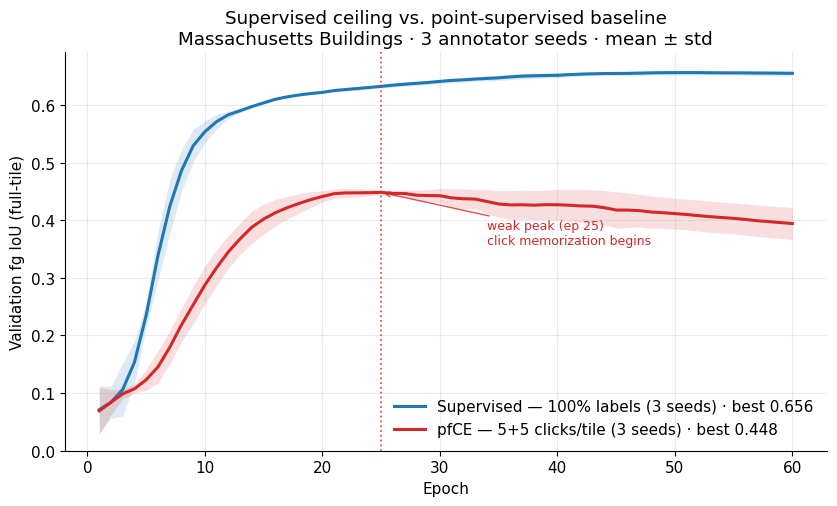

In [ ]:
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
C_SUP, C_WEAK = '#1f77b4', '#d62728'

def to_array(d):
    n = max(len(c) for c in d.values())
    a = np.full((len(d), n), np.nan)
    for i, c in enumerate(d.values()): a[i, :len(c)] = c
    return a

fig, ax = plt.subplots(figsize=(8.5, 5.2))
for d, color, label in [(sup_curves, C_SUP,  f'Supervised — 100% labels ({len(sup_curves)} seeds)'),
                        (weak_curves, C_WEAK, f'pfCE — 5+5 clicks/tile ({len(weak_curves)} seeds)')]:
    arr = to_array(d); m, s = np.nanmean(arr, 0), np.nanstd(arr, 0)
    x = np.arange(1, len(m) + 1)
    ax.plot(x, m, color=color, lw=2.2, label=f"{label} · best {np.nanmax(m):.3f}")
    ax.fill_between(x, m - s, m + s, color=color, alpha=0.15, lw=0)

wm = np.nanmean(to_array(weak_curves), 0); pk = int(np.nanargmax(wm)) + 1
ax.axvline(pk, color=C_WEAK, ls=':', lw=1.3, alpha=0.8)
ax.annotate(f'weak peak (ep {pk})\nclick memorization begins', xy=(pk, wm.max()),
            xytext=(pk + 9, wm.max() - 0.09), fontsize=9, color=C_WEAK,
            arrowprops=dict(arrowstyle='->', color=C_WEAK, alpha=0.8))

ax.set_xlabel('Epoch'); ax.set_ylabel('Validation fg IoU (full-tile)')
ax.set_title('Supervised ceiling vs. point-supervised baseline\n'
             'Massachusetts Buildings · 3 annotator seeds · mean ± std')
ax.grid(alpha=0.25); ax.legend(loc='lower right', frameon=False); ax.set_ylim(0, None)
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(Path(CFG.run_dir) / f'week1_curves.{ext}', dpi=300, bbox_inches='tight')
plt.show()

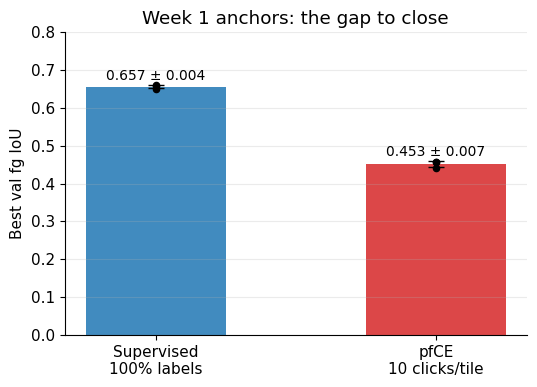

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 4))
groups = [(sup_curves, C_SUP, 'Supervised\n100% labels'), (weak_curves, C_WEAK, 'pfCE\n10 clicks/tile')]
for i, (d, color, label) in enumerate(groups):
    bests = [c.max() for c in d.values()]
    ax.bar(i, np.mean(bests), yerr=np.std(bests), capsize=6, color=color, alpha=0.85, width=0.5)
    ax.scatter([i] * len(bests), bests, color='k', s=20, zorder=3)
    ax.text(i, np.mean(bests) + np.std(bests) + 0.012, f'{np.mean(bests):.3f} ± {np.std(bests):.3f}',
            ha='center', fontsize=10)
ax.set_xticks([0, 1]); ax.set_xticklabels([g[2] for g in groups])
ax.set_ylabel('Best val fg IoU'); ax.set_ylim(0, 0.8); ax.grid(axis='y', alpha=0.25)
ax.set_title('Week 1 anchors: the gap to close')
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(Path(CFG.run_dir) / f'week1_anchors.{ext}', dpi=300, bbox_inches='tight')
plt.show()

We trained a U-Net (ResNet-34 encoder) on the Massachusetts Buildings dataset under two supervision regimes with an identical training recipe. With full pixel labels, the model reaches a test foreground IoU of 0.711 ± 0.001. With only 10 point annotations per tile (5 building, 5 background — about 0.0004% of pixels), the same model reaches 0.494 ± 0.002, i.e., ~70% of fully-supervised performance. The gap is the point-to-mask problem: clicks teach the model what buildings look like, but not where each building ends. The weak model also memorizes its 1,370 training points after ~25 epochs — training loss keeps falling while dense quality slowly declines. All experiments use frozen, seeded point sets (one simulated annotator per seed), a training dataset that cannot access dense labels, and a test set evaluated exactly once at the end. Results reproduced across two independent sessions.

# Week 2

In [28]:
from skimage.segmentation import slic
import torchvision

W2 = {
    'n_sweep':     [5, 10, 25, 50, 100],   # clicks per class per tile
    'reps':        [0, 1, 2],              # 3 simulated annotators
    'sigma':       8.0,                    # Gaussian blob size (pixels)
    'k':           8,                      # kNN neighbours
    'tau':         0.6,                    # kNN confidence gate
    'slic_scales': [1000, 2000, 4000],     # superpixel grids per tile
    'cache_dir':   str(Path(CFG.run_dir) / 'w2_cache'),
}
Path(W2['cache_dir']).mkdir(parents=True, exist_ok=True)

# Frozen ImageNet ResNet-34, cut at layer3: object-level features, decent detail
_resnet = torchvision.models.resnet34(
    weights=torchvision.models.ResNet34_Weights.IMAGENET1K_V1).to(DEVICE).eval()

class FeatureNet(nn.Module):
    def __init__(self, net):
        super().__init__()
        self.net = nn.Sequential(net.conv1, net.bn1, net.relu, net.maxpool,
                                 net.layer1, net.layer2, net.layer3)
    def forward(self, x): return self.net(x)     # (B, 256, H/16, W/16)

FEATURE_NET = FeatureNet(_resnet)
for p in FEATURE_NET.parameters(): p.requires_grad_(False)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 127MB/s]


In [29]:
# ============ GROWER 1: Gaussian blobs (the simple baseline) ============
def gaussian_propagate(pts, sigma=W2['sigma']):
    """Soft disk around every click; a pixel takes the label of the closer click type."""
    fg = (pts == 1.0).float()[None, None]
    bg = (pts == 0.0).float()[None, None]
    r = int(2.5 * sigma)
    ax = torch.arange(-r, r + 1, dtype=torch.float32)
    k1 = torch.exp(-(ax ** 2) / (2 * sigma ** 2)); k1 = (k1 / k1.max()).view(1, 1, 1, -1)
    def blur(x):
        x = F.conv2d(x, k1, padding=(0, r))
        return F.conv2d(x, k1.reshape(1, 1, -1, 1), padding=(r, 0))
    wfg, wbg = blur(fg)[0, 0], blur(bg)[0, 0]
    pseudo = torch.full_like(pts, -1.0)
    pseudo[(wfg > 0.05) & (wfg >= wbg)] = 1.0
    pseudo[(wbg > 0.05) & (wbg >  wfg)] = 0.0
    return pseudo

# ============ GROWER 2: SLIC superpixels, multi-scale vote ============
def slic_vote(seg, pts):
    """Every superpixel gets the majority label of clicks inside it (vectorised)."""
    seg = seg.reshape(-1).long(); p = pts.reshape(-1)
    n = int(seg.max().item()) + 1
    fg_cnt = torch.bincount(seg[p == 1.0], minlength=n)
    bg_cnt = torch.bincount(seg[p == 0.0], minlength=n)
    lab = torch.full((n,), -1.0)
    lab[(fg_cnt > bg_cnt)] = 1.0
    lab[(bg_cnt > fg_cnt)] = 0.0        # ties stay unlabeled
    return lab[seg].reshape(pts.shape).float()

def slic_propagate(segs, pts):
    """3 superpixel grids; a pixel is labeled only if >= 2 of 3 grids agree."""
    votes = torch.stack([slic_vote(s, pts) for s in segs])
    fg = (votes == 1.0).sum(0); bg = (votes == 0.0).sum(0)
    out = torch.full_like(pts, -1.0)
    out[fg >= 2] = 1.0
    out[bg >= 2] = 0.0
    return out

# ============ GROWER 3: feature-space k-NN ============
@torch.no_grad()
def knn_propagate(feats, pts, k=W2['k'], tau=W2['tau']):
    """Each pixel asks: 'which k clicked pixels do I resemble most?' (cosine, fp16)."""
    dev = feats.device; p = pts.to(dev)
    fg_xy, bg_xy = torch.nonzero(p == 1.0), torch.nonzero(p == 0.0)
    seeds = torch.cat([feats[:, fg_xy[:, 0], fg_xy[:, 1]],
                       feats[:, bg_xy[:, 0], bg_xy[:, 1]]], dim=1).T      # (S,C)
    y = torch.cat([torch.ones(len(fg_xy)), torch.zeros(len(bg_xy))]).to(dev)
    seeds = F.normalize(seats := seeds.float(), dim=1).half()
    sim = torch.einsum('chw,sc->shw', feats, seeds)                      # (S,H,W)
    v, i = sim.topk(min(k, len(y)), dim=0)
    votes = y[i]                                          # (k,H,W)
    conf, frac = v.float().mean(0), votes.mean(0)
    pseudo = torch.full_like(p, -1.0)
    ok = conf > tau
    pseudo[ok & (frac >= 0.5)] = 1.0
    pseudo[ok & (frac <  0.5)] = 0.0
    return pseudo.cpu()

# ============ CONSENSUS: keep pixels where >= 2 growers agree ============
def consensus(*maps, min_agree=2):
    stack = torch.stack([m.float() for m in maps])
    fg = (stack == 1.0).sum(0); bg = (stack == 0.0).sum(0)
    out = torch.full_like(stack[0], -1.0)
    out[fg >= min_agree] = 1.0
    out[bg >= min_agree] = 0.0
    return out

# ============ helpers to load cached per-tile artifacts ============
def load_slic(tid):
    z = np.load(Path(W2['cache_dir']) / 'slic' / f'{tid}.npz')
    return [torch.from_numpy(z[kk].astype(np.int64)) for kk in z.files]

def load_feats(tid):
    f = torch.load(Path(W2['cache_dir']) / 'feat' / f'{tid}.pt').to(DEVICE).float()
    f = F.interpolate(f[None], size=store_train.tile_shape,
                      mode='bilinear', align_corners=False)[0]
    return F.normalize(f, dim=0).half()          # (256,H,W) fp16

In [30]:
# ============ GROWER 1: Gaussian blobs (the simple baseline) ============ CPU VERSION FOR CHECKING
def gaussian_propagate(pts, sigma=W2['sigma']):
    """Soft disk around every click; a pixel takes the label of the closer click type."""
    fg = (pts == 1.0).float()[None, None]
    bg = (pts == 0.0).float()[None, None]
    r = int(2.5 * sigma)
    ax = torch.arange(-r, r + 1, dtype=torch.float32)
    k1 = torch.exp(-(ax ** 2) / (2 * sigma ** 2)); k1 = (k1 / k1.max()).view(1, 1, 1, -1)
    def blur(x):
        x = F.conv2d(x, k1, padding=(0, r))
        return F.conv2d(x, k1.reshape(1, 1, -1, 1), padding=(r, 0))
    wfg, wbg = blur(fg)[0, 0], blur(bg)[0, 0]
    pseudo = torch.full_like(pts, -1.0)
    pseudo[(wfg > 0.05) & (wfg >= wbg)] = 1.0
    pseudo[(wbg > 0.05) & (wbg >  wfg)] = 0.0
    return pseudo

# ============ GROWER 1: Gaussian blobs (the simple baseline) ============
def gaussian_propagate_gpu(pts, sigma=W2['sigma']):
    dev = pts.device
    fg = (pts == 1.0).float()[None, None]
    bg = (pts == 0.0).float()[None, None]
    r = int(2.5 * sigma)
    ax = torch.arange(-r, r + 1, device=dev, dtype=torch.float32)
    k1 = torch.exp(-(ax ** 2) / (2 * sigma ** 2)); k1 = (k1 / k1.max()).view(1, 1, 1, -1)
    def blur(x):
        x = F.conv2d(x, k1, padding=(0, r))
        return F.conv2d(x, k1.reshape(1, 1, -1, 1), padding=(r, 0))
    wfg, wbg = blur(fg)[0, 0], blur(bg)[0, 0]
    pseudo = torch.full_like(pts, -1.0)
    pseudo[(wfg > 0.05) & (wfg >= wbg)] = 1.0
    pseudo[(wbg > 0.05) & (wbg >  wfg)] = 0.0
    return pseudo

# ============ GROWER 2: SLIC superpixels, multi-scale vote ============
def slic_vote_gpu(seg, pts):                      # seg & pts on GPU
    n = int(seg.max().item()) + 1
    dev = seg.device
    fg_idx, bg_idx = seg[pts == 1.0], seg[pts == 0.0]
    fg_cnt = torch.zeros(n, device=dev, dtype=torch.long).index_add_(
        0, fg_idx, torch.ones(fg_idx.numel(), device=dev, dtype=torch.long))
    bg_cnt = torch.zeros(n, device=dev, dtype=torch.long).index_add_(
        0, bg_idx, torch.ones(bg_idx.numel(), device=dev, dtype=torch.long))
    lab = torch.full((n,), -1.0, device=dev)
    lab[fg_cnt > bg_cnt] = 1.0
    lab[bg_cnt > fg_cnt] = 0.0
    return lab[seg]                               # 2.25M gather, now on GPU

def slic_propagate_gpu(segs, pts):
    votes = torch.stack([slic_vote_gpu(s, pts) for s in segs])
    fg = (votes == 1.0).sum(0); bg = (votes == 0.0).sum(0)
    out = torch.full_like(pts, -1.0)
    out[fg >= 2] = 1.0
    out[bg >= 2] = 0.0
    return out

# ============ GROWER 3: feature-space k-NN ============
@torch.no_grad()
def knn_propagate_gpu(feats, pts, k=W2['k'], tau=W2['tau']):
    fg_xy, bg_xy = torch.nonzero(pts == 1.0), torch.nonzero(pts == 0.0)
    seeds = torch.cat([feats[:, fg_xy[:, 0], fg_xy[:, 1]],
                       feats[:, bg_xy[:, 0], bg_xy[:, 1]]], dim=1).T
    y = torch.cat([torch.ones(len(fg_xy), device=pts.device),
                   torch.zeros(len(bg_xy), device=pts.device)])
    seeds = F.normalize(seeds.float(), dim=1).half()
    sim = torch.einsum('chw,sc->shw', feats, seeds)
    v, i = sim.topk(min(k, len(y)), dim=0)
    conf, frac = v.float().mean(0), y[i].mean(0)
    pseudo = torch.full_like(pts, -1.0)
    ok = conf > tau
    pseudo[ok & (frac >= 0.5)] = 1.0
    pseudo[ok & (frac <  0.5)] = 0.0
    return pseudo

# ============ CONSENSUS: keep pixels where >= 2 growers agree ============
def consensus_gpu(*maps):
    stack = torch.stack([m.float() for m in maps])
    fg = (stack == 1.0).sum(0); bg = (stack == 0.0).sum(0)
    out = torch.full_like(stack[0], -1.0)
    out[fg >= 2] = 1.0
    out[bg >= 2] = 0.0
    return out


# ============ helpers to load cached per-tile artifacts ============
def load_slic(tid):
    z = np.load(Path(W2['cache_dir']) / 'slic' / f'{tid}.npz')
    return [torch.from_numpy(z[kk].astype(np.int64)) for kk in z.files]

def load_feats(tid):
    f = torch.load(Path(W2['cache_dir']) / 'feat' / f'{tid}.pt').to(DEVICE).float()
    f = F.interpolate(f[None], size=store_train.tile_shape,
                      mode='bilinear', align_corners=False)[0]
    return F.normalize(f, dim=0).half()          # (256,H,W) fp16

In [ ]:
slic_dir = Path(W2['cache_dir']) / 'slic'; slic_dir.mkdir(exist_ok=True)
feat_dir = Path(W2['cache_dir']) / 'feat'; feat_dir.mkdir(exist_ok=True)

for i, tid in enumerate(store_train.ids):
    if not (slic_dir / f'{tid}.npz').exists():
        img = store_train.images[i].permute(1, 2, 0).numpy()          # H,W,3 uint8
        segs = [slic(img, n_segments=n, compactness=12, sigma=1.0,
                     start_label=0, channel_axis=-1).astype(np.int16)
                for n in W2['slic_scales']]
        np.savez_compressed(slic_dir / f'{tid}.npz', *segs)
    if (i + 1) % 20 == 0: print(f'SLIC {i+1}/137...')

for i, tid in enumerate(store_train.ids):
    if not (feat_dir / f'{tid}.pt').exists():
        x = TF.normalize(store_train.images[i].float().div(255.0),
                        IMAGENET_MEAN, IMAGENET_STD).to(DEVICE)
        with torch.no_grad():
            f = FEATURE_NET(x.unsqueeze(0))[0]                        # (256, 94, 94)
        torch.save(f.half().cpu(), feat_dir / f'{tid}.pt')
    if (i + 1) % 20 == 0: print(f'features {i+1}/137...')
print('Per-tile artifacts ready (on Drive, crash-safe).')

SLIC 20/137...
SLIC 40/137...
SLIC 60/137...
SLIC 80/137...
SLIC 100/137...
SLIC 120/137...
features 20/137...
features 40/137...
features 60/137...
features 80/137...
features 100/137...
features 120/137...
Per-tile artifacts ready (on Drive, crash-safe).


In [31]:
def score_pseudo_gpu(pseudo, gt):
    pred = (pseudo == 1.0)
    tp, fp = (pred & gt).sum(), (pred & ~gt).sum()
    fn = ((~pred) & gt).sum()
    pfg = (pseudo != -1.0) & pred
    tp_lab = (pfg & gt).sum()
    return {'iou': (tp / (tp + fp + fn).clamp(min=1)).item(),
            'precision': (tp_lab / pfg.sum().clamp(min=1)).item(),
            'recall': (tp / gt.sum().clamp(min=1)).item(),
            'coverage': ((pseudo != -1.0).sum() / pseudo.numel()).item()}

In [ ]:
# ---- smoke check: GPU must agree with the CPU version on one tile ----
t = 0
pts = sample_tile_points(store_train.masks[t], 25, SPLIT_OFFSET['train'] + 0)
g_cpu = gaussian_propagate(pts)
g_gpu = gaussian_propagate_gpu(pts.to(DEVICE)).cpu()
print('gaussian: pixels differing CPU vs GPU =',
      (g_cpu != g_gpu).sum().item(), '/', g_cpu.numel(), '(should be ~0)')

gaussian: pixels differing CPU vs GPU = 0 / 2250000 (should be ~0)


In [ ]:
# ================= THE ACCELERATED LOOP =================
import pandas as pd
partial = Path(W2['cache_dir']) / 'w2_partial.csv'
partial.unlink(missing_ok=True)          # fresh start (delete this line to resume instead)

rows, done = [], set()
t0 = time.time()
for t in range(len(store_train)):
    tid = store_train.ids[t]
    segs = [s.to(DEVICE) for s in load_slic(tid)]       # to GPU ONCE per tile
    feats = load_feats(tid)                             # already on GPU
    gt = store_train.masks[t].to(DEVICE)                # to GPU ONCE per tile
    for N in W2['n_sweep']:
        for rep in W2['reps']:
            # sampling stays on CPU (same seeds -> same clicks -> comparable)
            pts = sample_tile_points(store_train.masks[t], N,
                                     SPLIT_OFFSET['train'] + 1000 * rep + t).to(DEVICE)
            g = gaussian_propagate_gpu(pts)
            s = slic_propagate_gpu(segs, pts)
            k = knn_propagate_gpu(feats, pts)
            c = consensus_gpu(g, s, k)
            for method, ps in [('gauss', g), ('slic', s), ('knn', k), ('cons', c)]:
                rows.append(dict(method=method, N=N, rep=rep, tile=t,
                                 **score_pseudo_gpu(ps, gt)))
    if (t + 1) % 10 == 0:
        pd.DataFrame(rows).to_csv(partial, index=False)
        torch.cuda.empty_cache()
        eta = (time.time() - t0) / (t + 1) * (137 - t - 1)
        print(f'tile {t+1}/137 | {time.time()-t0:.0f}s elapsed | ETA {eta/60:.0f} min | '
              f'GPU mem {torch.cuda.memory_allocated()/1e9:.1f} GB')

df = pd.DataFrame(rows)
df.to_csv(Path(CFG.run_dir) / 'w2_pseudo_quality.csv', index=False)
print(f'\nSaved w2_pseudo_quality.csv — {len(df)} measurements in '
      f'{(time.time()-t0)/60:.0f} min')

tile 10/137 | 37s elapsed | ETA 8 min | GPU mem 1.4 GB
tile 20/137 | 76s elapsed | ETA 7 min | GPU mem 1.4 GB
tile 30/137 | 116s elapsed | ETA 7 min | GPU mem 1.4 GB
tile 40/137 | 155s elapsed | ETA 6 min | GPU mem 1.4 GB
tile 50/137 | 194s elapsed | ETA 6 min | GPU mem 1.4 GB
tile 60/137 | 240s elapsed | ETA 5 min | GPU mem 1.4 GB
tile 70/137 | 279s elapsed | ETA 4 min | GPU mem 1.4 GB
tile 80/137 | 321s elapsed | ETA 4 min | GPU mem 1.4 GB
tile 90/137 | 359s elapsed | ETA 3 min | GPU mem 1.4 GB
tile 100/137 | 395s elapsed | ETA 2 min | GPU mem 1.4 GB
tile 110/137 | 435s elapsed | ETA 2 min | GPU mem 1.4 GB
tile 120/137 | 471s elapsed | ETA 1 min | GPU mem 1.4 GB
tile 130/137 | 508s elapsed | ETA 0 min | GPU mem 1.4 GB

Saved w2_pseudo_quality.csv — 8220 measurements in 9 min


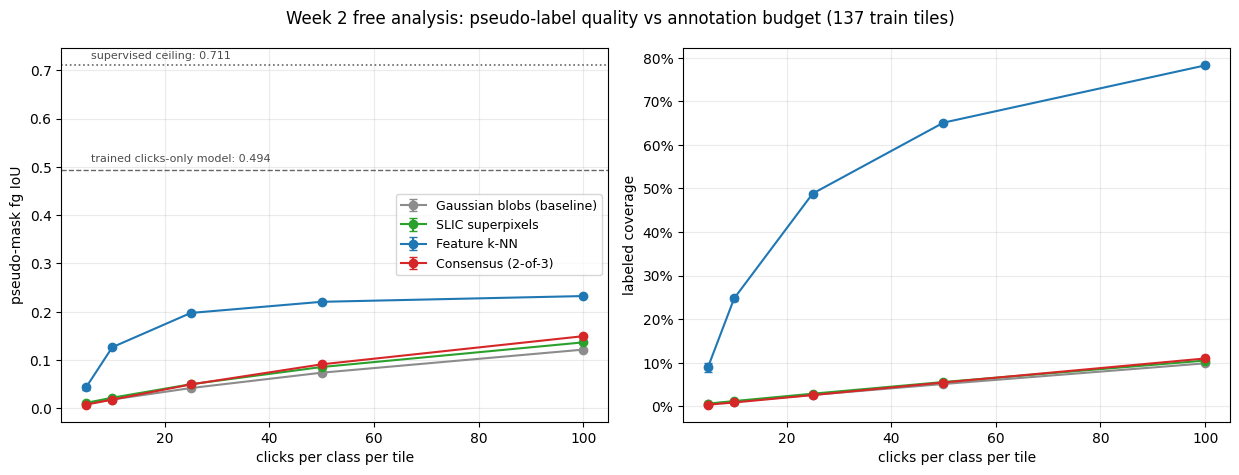

--- N = 25 clicks per class ---
  knn    IoU 0.197±0.000 | precision 25.3% | recall 54.5%
  slic   IoU 0.050±0.001 | precision 39.1% | recall 5.5%
  cons   IoU 0.049±0.001 | precision 39.5% | recall 5.5%
  gauss  IoU 0.042±0.000 | precision 37.8% | recall 4.6%
--- N = 50 clicks per class ---
  knn    IoU 0.220±0.001 | precision 25.2% | recall 68.8%
  cons   IoU 0.091±0.001 | precision 38.8% | recall 11.1%
  slic   IoU 0.085±0.001 | precision 38.4% | recall 10.3%
  gauss  IoU 0.074±0.001 | precision 37.4% | recall 8.7%
--- N = 100 clicks per class ---
  knn    IoU 0.232±0.000 | precision 25.1% | recall 78.9%
  cons   IoU 0.149±0.001 | precision 38.3% | recall 20.9%
  slic   IoU 0.136±0.001 | precision 38.0% | recall 18.6%
  gauss  IoU 0.121±0.000 | precision 37.0% | recall 16.2%


In [ ]:
from matplotlib import pyplot as plt
def band(metric):
    pr = df.groupby(['method', 'N', 'rep'])[metric].mean().reset_index()
    return pr.groupby(['method', 'N'])[metric].agg(['mean', 'std']).reset_index()

iou_b, cov_b = band('iou'), band('coverage')
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
styles = [('gauss', '#8c8c8c', 'Gaussian blobs (baseline)'),
          ('slic',  '#2ca02c', 'SLIC superpixels'),
          ('knn',   '#1f77b4', 'Feature k-NN'),
          ('cons',  '#d62728', 'Consensus (2-of-3)')]
for m, col, lbl in styles:
    sub = iou_b[iou_b.method == m]
    axes[0].errorbar(sub.N, sub['mean'], yerr=sub['std'], marker='o', color=col,
                     capsize=3, label=lbl)
    sub = cov_b[cov_b.method == m]
    axes[1].errorbar(sub.N, sub['mean'], yerr=sub['std'], marker='o', color=col, capsize=3)
axes[0].axhline(0.494, ls='--', c='k', lw=1, alpha=0.6)
axes[0].text(6, 0.51, 'trained clicks-only model: 0.494', fontsize=8, alpha=0.7)
axes[0].axhline(0.711, ls=':', c='k', lw=1.2, alpha=0.6)
axes[0].text(6, 0.725, 'supervised ceiling: 0.711', fontsize=8, alpha=0.7)
axes[0].set_xlabel('clicks per class per tile'); axes[0].set_ylabel('pseudo-mask fg IoU')
axes[1].set_xlabel('clicks per class per tile'); axes[1].set_ylabel('labeled coverage')
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
axes[0].grid(alpha=0.25); axes[1].grid(alpha=0.25); axes[0].legend(fontsize=9)
fig.suptitle('Week 2 free analysis: pseudo-label quality vs annotation budget (137 train tiles)')
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(Path(CFG.run_dir) / f'w2_pseudo_quality.{ext}', dpi=300, bbox_inches='tight')
plt.show()

for Nq in (25, 50, 100):                               # the numbers to send me
    print(f'--- N = {Nq} clicks per class ---')
    sub = iou_b[iou_b.N == Nq].sort_values('mean', ascending=False)
    for _, r in sub.iterrows():
        pr = df[(df.method == r.method) & (df.N == Nq)]
        print(f"  {r.method:6s} IoU {r['mean']:.3f}±{r['std']:.3f} | "
              f"precision {pr['precision'].mean():.1%} | recall {pr['recall'].mean():.1%}")

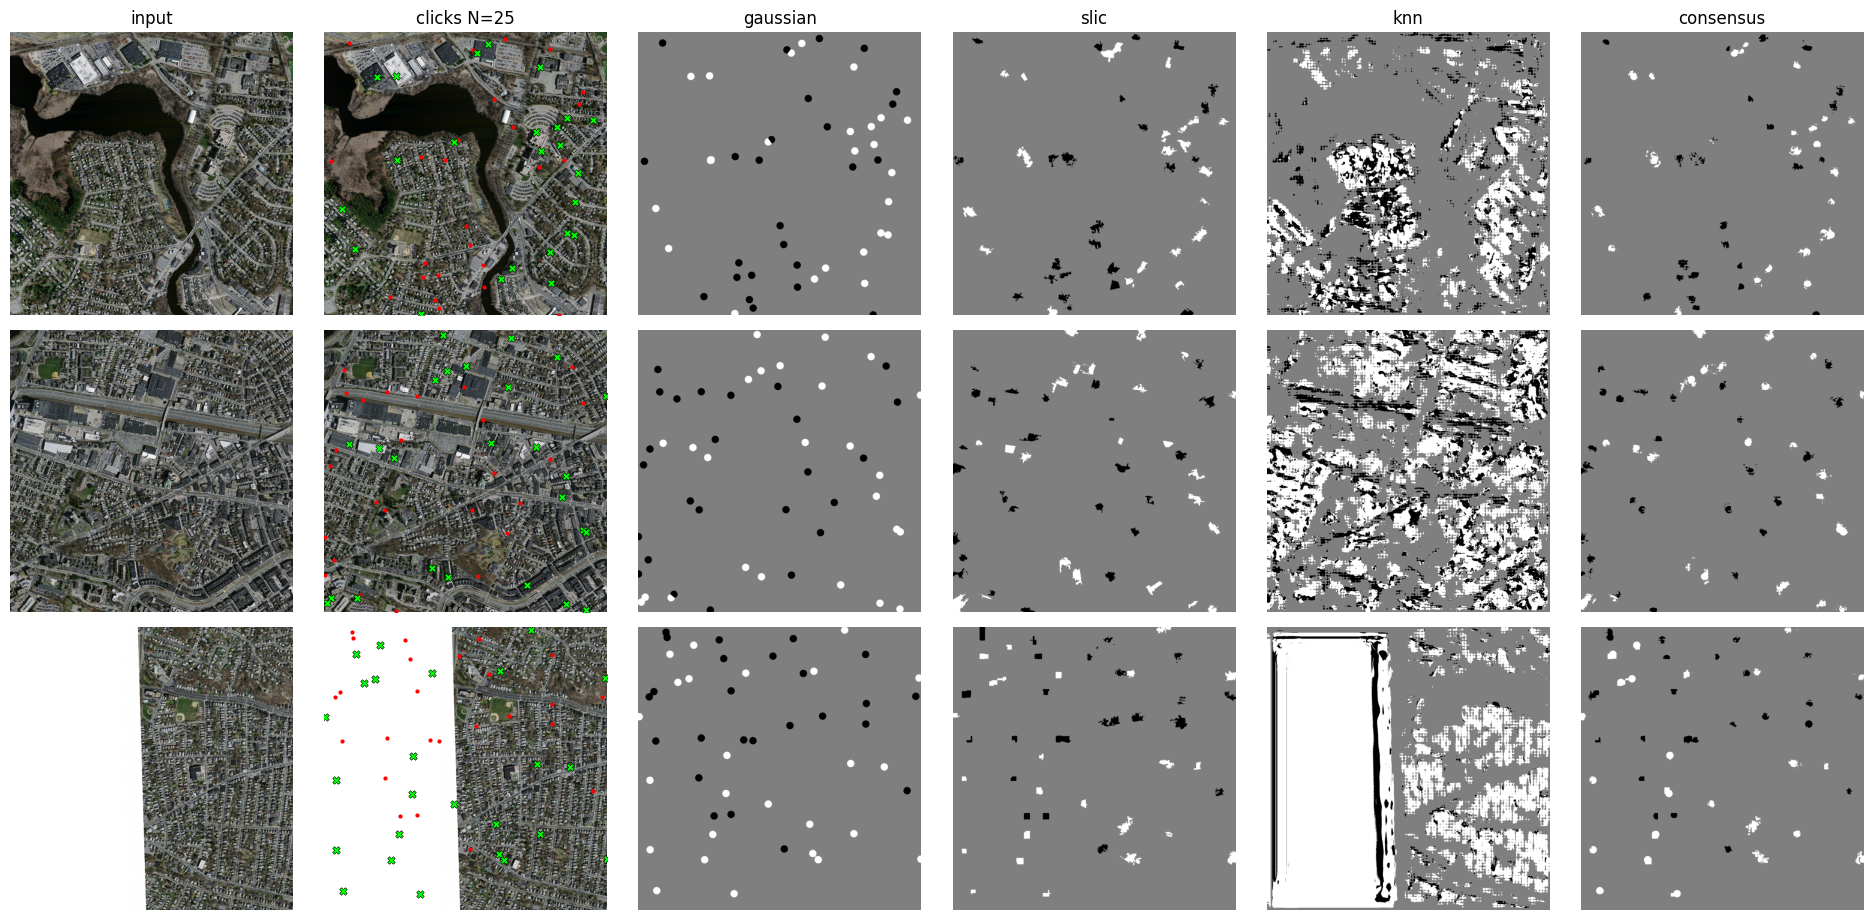

In [ ]:
def pseudo_to_rgb(p):
    """Converts a pseudo-label mask (-1.0=gray, 0.0=black, 1.0=white) into an RGB image array."""
    # Convert input to CPU tensor if necessary
    p_tensor = p.cpu() if isinstance(p, torch.Tensor) else torch.tensor(p)

    # Initialize a 3-channel float tensor filled with 0.5 (Gray for unassigned pixels)
    rgb = torch.full((3, *p_tensor.shape), 0.5, dtype=torch.float32)

    # Masks for active class regions
    fg_mask = (p_tensor == 1.0)
    bg_mask = (p_tensor == 0.0)

    # Assign RGB values directly across channels
    rgb[0, fg_mask] = 1.0  # R channel = 1.0
    rgb[1, fg_mask] = 1.0  # G channel = 1.0
    rgb[2, fg_mask] = 1.0  # B channel = 1.0 (White for Foreground)

    rgb[0, bg_mask] = 0.0  # R channel = 0.0
    rgb[1, bg_mask] = 0.0  # G channel = 0.0
    rgb[2, bg_mask] = 0.0  # B channel = 0.0 (Black for Background)

    return rgb.permute(1, 2, 0).numpy()                # white=fg, black=bg, gray=ignore

show, N_SHOW = [0, 25, 60], 25
fig, axes = plt.subplots(len(show), 6, figsize=(19, 3.1 * len(show)))
for row, t in enumerate(show):
    tid = store_train.ids[t]
    pts = sample_tile_points(store_train.masks[t], N_SHOW, SPLIT_OFFSET['train'] + t)
    maps = {'gaussian': gaussian_propagate(pts),
            'slic': slic_propagate(load_slic(tid), pts),
            'knn': knn_propagate(load_feats(tid), pts)}
    maps['consensus'] = consensus(*maps.values())
    img = store_train.images[t].permute(1, 2, 0).numpy()
    axes[row, 0].imshow(img)
    axes[row, 1].imshow(img)
    fg, bg = torch.nonzero(pts == 1.0), torch.nonzero(pts == 0.0)
    axes[row, 1].scatter(bg[:, 1], bg[:, 0], s=4, c='red')
    axes[row, 1].scatter(fg[:, 1], fg[:, 0], s=30, c='lime', marker='X',
                         edgecolors='k', linewidths=0.4)
    for j, (nm, ps) in enumerate(maps.items()):
        axes[row, 2 + j].imshow(pseudo_to_rgb(ps))
        if row == 0: axes[row, 2 + j].set_title(nm)
    if row == 0: axes[row, 0].set_title('input'); axes[row, 1].set_title(f'clicks N={N_SHOW}')
for ax in axes.flat: ax.axis('off')
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(Path(CFG.run_dir) / f'w2_overlays.{ext}', dpi=300, bbox_inches='tight')
plt.show()

#re-build everything at object scale (~20px)

### V2-A — new caches (≈15 min, resumable)

In [ ]:
slic_fine = Path(W2['cache_dir']) / 'slic_fine'; slic_fine.mkdir(exist_ok=True)
feat_l1 = Path(W2['cache_dir']) / 'feat_l1'; feat_l1.mkdir(exist_ok=True)
feat_l2 = Path(W2['cache_dir']) / 'feat_l2'; feat_l2.mkdir(exist_ok=True)

# segments now BRACKET the building size: ~900px / ~450px / ~225px each
for i, tid in enumerate(store_train.ids):
    if not (slic_fine / f'{tid}.npz').exists():
        img = store_train.images[i].permute(1, 2, 0).numpy()
        segs = [slic(img, n_segments=n, compactness=12, sigma=1.0,
                     start_label=0, channel_axis=-1).astype(np.int16)
                for n in (2500, 5000, 10000)]          # order: 2500, 5000, 10000
        np.savez_compressed(slic_fine / f'{tid}.npz', *segs)
    if (i + 1) % 20 == 0: print(f'fine SLIC {i+1}/137...')

class FeatureNetShallow(nn.Module):     # earlier layers = finer resolution
    def __init__(self, net, depth):
        super().__init__()
        blocks = [net.conv1, net.bn1, net.relu, net.maxpool, net.layer1]
        if depth == 2: blocks.append(net.layer2)
        self.net = nn.Sequential(*blocks)
    def forward(self, x): return self.net(x)   # depth1: (64, H/4, W/4) | depth2: (128, H/8, W/8)

FEAT1, FEAT2 = FeatureNetShallow(_resnet, 1), FeatureNetShallow(_resnet, 2)

@torch.no_grad()
def _save_feats(net, out_dir, i, tid):
    x = TF.normalize(store_train.images[i].float().div(255.0),
                     IMAGENET_MEAN, IMAGENET_STD).to(DEVICE)
    torch.save(net(x.unsqueeze(0))[0].half().cpu(), out_dir / f'{tid}.pt')

for i, tid in enumerate(store_train.ids):
    if not (feat_l1 / f'{tid}.pt').exists(): _save_feats(FEAT1, feat_l1, i, tid)
    if not (feat_l2 / f'{tid}.pt').exists(): _save_feats(FEAT2, feat_l2, i, tid)
    if (i + 1) % 20 == 0: print(f'features L1/L2 {i+1}/137...')

def load_slic_fine(tid):
    z = np.load(slic_fine / f'{tid}.npz')
    return [torch.from_numpy(z[kk].astype(np.int64)).to(DEVICE) for kk in z.files]

def load_feats_v2(tid, depth):
    d = feat_l1 if depth == 1 else feat_l2
    f = torch.load(d / f'{tid}.pt').to(DEVICE).float()
    f = F.interpolate(f[None], size=store_train.tile_shape,
                      mode='bilinear', align_corners=False)[0]
    return F.normalize(f, dim=0).half()
print('V2 caches ready.')

fine SLIC 20/137...
fine SLIC 40/137...
fine SLIC 60/137...
fine SLIC 80/137...
fine SLIC 100/137...
fine SLIC 120/137...
features L1/L2 20/137...
features L1/L2 40/137...
features L1/L2 60/137...
features L1/L2 80/137...
features L1/L2 100/137...
features L1/L2 120/137...
V2 caches ready.


In [ ]:
N_SWEEP, REP = 50, 0            # one click budget, one annotator — enough to rank configs
configs = {
    'gauss σ=3':   lambda pts, S: gaussian_propagate_gpu(pts, sigma=3.0),
    'gauss σ=5':   lambda pts, S: gaussian_propagate_gpu(pts, sigma=5.0),
    'slic 2.5k':   lambda pts, S: slic_vote_gpu(S['segs'][0], pts),
    'slic 5k':     lambda pts, S: slic_vote_gpu(S['segs'][1], pts),
    'slic 10k':    lambda pts, S: slic_vote_gpu(S['segs'][2], pts),
    'slic multi':  lambda pts, S: slic_propagate_gpu(S['segs'], pts),
    'knn L1 τ.75': lambda pts, S: knn_propagate_gpu(S['f1'], pts, tau=0.75),
    'knn L1 τ.85': lambda pts, S: knn_propagate_gpu(S['f1'], pts, tau=0.85),
    'knn L2 τ.75': lambda pts, S: knn_propagate_gpu(S['f2'], pts, tau=0.75),
    'knn L2 τ.85': lambda pts, S: knn_propagate_gpu(S['f2'], pts, tau=0.85),
}

results = {name: [] for name in configs}
for t in range(len(store_train)):
    tid = store_train.ids[t]
    S = {'segs': load_slic_fine(tid), 'f1': load_feats_v2(tid, 1), 'f2': load_feats_v2(tid, 2)}
    gt = store_train.masks[t].to(DEVICE)
    pts = sample_tile_points(store_train.masks[t], N_SWEEP,
                             SPLIT_OFFSET['train'] + 1000 * REP + t).to(DEVICE)
    for name, fn in configs.items():
        results[name].append(score_pseudo_gpu(fn(pts, S), gt))
    if (t + 1) % 25 == 0: print(f'{t+1}/137 tiles swept')

print(f'\n=== V2 sweep — N={N_SWEEP}, rep={REP}, 137 tiles ===')
print('(V1 reference: knn L3 τ.60 → IoU 0.220 | prec 25.2% | recall 68.8%)\n')
for name, accs in results.items():
    d = pd.DataFrame(accs)
    print(f"{name:14s} IoU {d['iou'].mean():.3f} | prec {d['precision'].mean():5.1%} | "
          f"recall {d['recall'].mean():5.1%} | coverage {d['coverage'].mean():5.1%}")

25/137 tiles swept
50/137 tiles swept
75/137 tiles swept
100/137 tiles swept
125/137 tiles swept

=== V2 sweep — N=50, rep=0, 137 tiles ===
(V1 reference: knn L3 τ.60 → IoU 0.220 | prec 25.2% | recall 68.8%)

gauss σ=3      IoU 0.024 | prec 63.4% | recall  2.4% | coverage  0.8%
gauss σ=5      IoU 0.045 | prec 48.6% | recall  4.8% | coverage  2.1%
slic 2.5k      IoU 0.079 | prec 36.7% | recall  9.6% | coverage  5.5%
slic 5k        IoU 0.051 | prec 43.9% | recall  5.6% | coverage  2.6%
slic 10k       IoU 0.032 | prec 53.9% | recall  3.3% | coverage  1.2%
slic multi     IoU 0.047 | prec 49.1% | recall  5.1% | coverage  2.1%
knn L1 τ.75    IoU 0.234 | prec 27.1% | recall 67.7% | coverage 99.8%
knn L1 τ.85    IoU 0.172 | prec 27.0% | recall 38.4% | coverage 72.3%
knn L2 τ.75    IoU 0.163 | prec 29.9% | recall 33.3% | coverage 40.2%
knn L2 τ.85    IoU 0.018 | prec 11.5% | recall  7.7% | coverage 10.7%


# Week 3

### ST-1 — ensemble pseudo-labels + quality check

In [31]:
import pandas as pd

models = []
for seed in CFG.seeds:
    m = get_model(pretrained=False)
    m.load_state_dict(torch.load(
        Path(CFG.run_dir) / f'pfce_n{CFG.n_points}_seed{seed}' / 'best.pt',
        map_location=DEVICE))
    m.eval(); models.append(m)
print('loaded', len(models), 'click-trained models')

@torch.no_grad()
def ensemble_prob(t):
    x = TF.normalize(store_train.images[t].float().div(255.0),
                     IMAGENET_MEAN, IMAGENET_STD).to(DEVICE)
    return torch.stack([windowed_infer(m, x) for m in models]).mean(0).cpu()

probs, t0 = [], time.time()
for t in range(len(store_train)):
    probs.append(ensemble_prob(t))
    if (t + 1) % 20 == 0: print(f'predicted {t+1}/137 | {time.time()-t0:.0f}s')
torch.save([p.half() for p in probs], Path(CFG.run_dir) / 'w2_cache' / 'ens_probs.pt')

def build_pseudo(t, hi, lo):
    p = probs[t].float()
    pseudo = torch.full_like(p, -1.0)
    pseudo[p > hi] = 1.0
    pseudo[p < lo] = 0.0
    for rep in CFG.seeds:                       # real clicks = anchors, always kept
        pts = sample_tile_points(store_train.masks[t], CFG.n_points,
                                 SPLIT_OFFSET['train'] + 1000 * rep + t)
        pseudo[pts == 1.0] = 1.0
        pseudo[pts == 0.0] = 0.0
    return pseudo

print('\nthreshold choice:')
for hi, lo in [(0.8, 0.2), (0.9, 0.1), (0.95, 0.05)]:
    rows = [score_pseudo_gpu(build_pseudo(t, hi, lo).to(DEVICE),
                             store_train.masks[t].to(DEVICE)) for t in range(137)]
    d = pd.DataFrame(rows)
    print(f'  ({hi}/{lo}): IoU {d["iou"].mean():.3f} | prec {d["precision"].mean():.1%} '
          f'| recall {d["recall"].mean():.1%} | cov {d["coverage"].mean():.1%}')

HI, LO = 0.9, 0.1                               # change if another clearly won
pseudo_train = [build_pseudo(t, HI, LO) for t in range(len(store_train))]
torch.save(pseudo_train, Path(CFG.run_dir) / 'w2_cache' / 'pseudo_selftrain.pt')
rows = [score_pseudo_gpu(pseudo_train[t].to(DEVICE),
                         store_train.masks[t].to(DEVICE)) for t in range(137)]
d = pd.DataFrame(rows)
print(f"\nFINAL pseudo-labels: IoU {d['iou'].mean():.3f} | prec {d['precision'].mean():.1%} "
      f"| recall {d['recall'].mean():.1%} | cov {d['coverage'].mean():.1%}")
print('(one-shot propagation managed only 0.234 — this must beat it clearly)')

loaded 3 click-trained models
predicted 20/137 | 18s
predicted 40/137 | 36s
predicted 60/137 | 54s
predicted 80/137 | 72s
predicted 100/137 | 90s
predicted 120/137 | 108s

threshold choice:
  (0.8/0.2): IoU 0.094 | prec 91.2% | recall 9.5% | cov 31.3%
  (0.9/0.1): IoU 0.002 | prec 96.1% | recall 0.2% | cov 0.1%
  (0.95/0.05): IoU 0.000 | prec 100.0% | recall 0.0% | cov 0.0%

FINAL pseudo-labels: IoU 0.002 | prec 96.1% | recall 0.2% | cov 0.1%
(one-shot propagation managed only 0.234 — this must beat it clearly)


In [32]:
import pandas as pd

probs = [p.float() for p in torch.load(Path(CFG.run_dir) / 'w2_cache' / 'ens_probs.pt')]

def build_pseudo(t, hi, lo):
    p = probs[t]
    pseudo = torch.full_like(p, -1.0)
    pseudo[p > hi] = 1.0
    pseudo[p < lo] = 0.0
    for rep in CFG.seeds:                       # click anchors, always kept
        pts = sample_tile_points(store_train.masks[t], CFG.n_points,
                                 SPLIT_OFFSET['train'] + 1000 * rep + t)
        pseudo[pts == 1.0] = 1.0
        pseudo[pts == 0.0] = 0.0
    return pseudo

print('lower thresholds — finding where the whisperer is still right:')
for hi, lo in [(0.75, 0.25), (0.70, 0.30), (0.65, 0.35), (0.60, 0.40), (0.55, 0.45)]:
    rows = [score_pseudo_gpu(build_pseudo(t, hi, lo).to(DEVICE),
                             store_train.masks[t].to(DEVICE)) for t in range(137)]
    d = pd.DataFrame(rows)
    print(f'  ({hi:.2f}/{lo:.2f}): IoU {d["iou"].mean():.3f} | prec {d["precision"].mean():.1%} '
          f'| recall {d["recall"].mean():.1%} | cov {d["coverage"].mean():.1%}')

lower thresholds — finding where the whisperer is still right:
  (0.75/0.25): IoU 0.189 | prec 87.6% | recall 19.5% | cov 48.0%
  (0.70/0.30): IoU 0.292 | prec 82.7% | recall 31.4% | cov 59.5%
  (0.65/0.35): IoU 0.380 | prec 76.8% | recall 43.4% | cov 68.5%
  (0.60/0.40): IoU 0.438 | prec 70.0% | recall 54.9% | cov 76.6%
  (0.55/0.45): IoU 0.461 | prec 62.6% | recall 64.9% | cov 84.3%


In [33]:
HI, LO = 0.70, 0.30
pseudo_train = [build_pseudo(t, HI, LO) for t in range(len(store_train))]
torch.save(pseudo_train, Path(CFG.run_dir) / 'w2_cache' / 'pseudo_selftrain.pt')

rows = [score_pseudo_gpu(pseudo_train[t].to(DEVICE),
                         store_train.masks[t].to(DEVICE)) for t in range(137)]
d = pd.DataFrame(rows)
print(f"SAVED: IoU {d['iou'].mean():.3f} | prec {d['precision'].mean():.1%} "
      f"| recall {d['recall'].mean():.1%} | cov {d['coverage'].mean():.1%}")

SAVED: IoU 0.292 | prec 82.7% | recall 31.4% | cov 59.5%


### leak-proof pseudo dataset + pilot training

In [20]:
class PseudoCropDataset(Dataset):
    """LEAK-PROOF: images + pseudo-masks only. Ground truth never enters."""
    def __init__(self, images, pseudo_maps, crop_size=CFG.crop_size,
                 crops_per_tile=CFG.crops_per_tile):
        self.images, self.pseudo = images, pseudo_maps
        self.crop_size, self.crops_per_tile = crop_size, crops_per_tile
    def __len__(self): return len(self.images) * self.crops_per_tile
    def __getitem__(self, idx):
        t = idx // self.crops_per_tile; cs = self.crop_size
        H, W = self.pseudo[t].shape
        top  = torch.randint(0, H - cs + 1, (1,)).item()
        left = torch.randint(0, W - cs + 1, (1,)).item()
        img = self.images[t][:, top:top+cs, left:left+cs]
        psm = self.pseudo[t][top:top+cs, left:left+cs]
        img, [psm] = geom_aug(img, [psm])
        img = TF.normalize(img.float() / 255.0, IMAGENET_MEAN, IMAGENET_STD)
        return {'image': img, 'points': psm.unsqueeze(0).float()}

In [34]:
pseudo_train = torch.load(Path(CFG.run_dir) / 'w2_cache' / 'pseudo_selftrain.pt')
st_hist = train_model('selftrain_r1', partial_focal_loss(),
                      PseudoCropDataset(store_train.images, pseudo_train),
                      store_val, None, seed=0, epochs=30)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

[selftrain_r1 s0] ep 001/30 | loss 0.1566 | val fgIoU 0.1047 bgIoU 0.3917 | best 0.1047@1 | 41s
[selftrain_r1 s0] ep 002/30 | loss 0.0380 | val fgIoU 0.1242 bgIoU 0.5729 | best 0.1242@2 | 35s
[selftrain_r1 s0] ep 003/30 | loss 0.0078 | val fgIoU 0.1545 bgIoU 0.7911 | best 0.1545@3 | 34s
[selftrain_r1 s0] ep 004/30 | loss 0.0032 | val fgIoU 0.1733 bgIoU 0.8719 | best 0.1733@4 | 34s
[selftrain_r1 s0] ep 005/30 | loss 0.0018 | val fgIoU 0.1846 bgIoU 0.8949 | best 0.1846@5 | 34s
[selftrain_r1 s0] ep 006/30 | loss 0.0012 | val fgIoU 0.2094 bgIoU 0.9018 | best 0.2094@6 | 34s
[selftrain_r1 s0] ep 007/30 | loss 0.0009 | val fgIoU 0.2434 bgIoU 0.9057 | best 0.2434@7 | 34s
[selftrain_r1 s0] ep 008/30 | loss 0.0008 | val fgIoU 0.2809 bgIoU 0.9088 | best 0.2809@8 | 34s
[selftrain_r1 s0] ep 009/30 | loss 0.0006 | val fgIoU 0.3164 bgIoU 0.9112 | best 0.3164@9 | 34s
[selftrain_r1 s0] ep 010/30 | loss 0.0008 | val fgIoU 0.3477 bgIoU 0.9129 | best 0.3477@10 | 34s
[selftrain_r1 s0] ep 011/30 | loss 0.00

In [35]:
m = get_model(pretrained=False)
m.load_state_dict(torch.load(Path(CFG.run_dir) / 'selftrain_r1_seed0' / 'best.pt',
                             map_location=DEVICE))
r = evaluate_on_tiles(m, store_test, None)
print(f"SELF-TRAIN ROUND 1 (pilot): test fg IoU {r['fg_iou']:.4f} | F1 {r['f1']:.4f}")
print("reference: clicks-only 0.494 | supervised ceiling 0.711")

SELF-TRAIN ROUND 1 (pilot): test fg IoU 0.5110 | F1 0.6764
reference: clicks-only 0.494 | supervised ceiling 0.711


### Round 2, Student becomes the teacher

In [36]:
student = get_model(pretrained=False)
student.load_state_dict(torch.load(Path(CFG.run_dir) / 'selftrain_r1_seed0' / 'best.pt',
                                    map_location=DEVICE))
student.eval()

@torch.no_grad()
def student_prob(t):
    x = TF.normalize(store_train.images[t].float().div(255.0),
                     IMAGENET_MEAN, IMAGENET_STD).to(DEVICE)
    return windowed_infer(student, x).cpu()

probs = [student_prob(t) for t in range(len(store_train))]   # replaces the old probs in memory
torch.save([p.half() for p in probs], Path(CFG.run_dir) / 'w2_cache' / 'r1_student_probs.pt')

def build_pseudo(t, hi, lo):
    p = probs[t]
    pseudo = torch.full_like(p, -1.0)
    pseudo[p > hi] = 1.0
    pseudo[p < lo] = 0.0
    for rep in CFG.seeds:
        pts = sample_tile_points(store_train.masks[t], CFG.n_points,
                                 SPLIT_OFFSET['train'] + 1000 * rep + t)
        pseudo[pts == 1.0] = 1.0
        pseudo[pts == 0.0] = 0.0
    return pseudo

print('round-2 threshold sweep (teacher = round-1 student):')
for hi, lo in [(0.75, 0.25), (0.70, 0.30), (0.65, 0.35)]:
    rows = [score_pseudo_gpu(build_pseudo(t, hi, lo).to(DEVICE),
                             store_train.masks[t].to(DEVICE)) for t in range(137)]
    d = pd.DataFrame(rows)
    print(f'  ({hi}/{lo}): IoU {d["iou"].mean():.3f} | prec {d["precision"].mean():.1%} '
          f'| recall {d["recall"].mean():.1%} | cov {d["coverage"].mean():.1%}')

round-2 threshold sweep (teacher = round-1 student):
  (0.75/0.25): IoU 0.430 | prec 61.2% | recall 58.8% | cov 85.2%
  (0.7/0.3): IoU 0.431 | prec 58.8% | recall 61.7% | cov 87.7%
  (0.65/0.35): IoU 0.430 | prec 56.5% | recall 65.4% | cov 91.0%


## The fix: put the student in a committee (2 minutes, zero new inference)

In [32]:
def build_pseudo(t, hi, lo):
    p = probs[t]
    pseudo = torch.full_like(p, -1.0)
    pseudo[p > hi] = 1.0
    pseudo[p < lo] = 0.0
    for rep in CFG.seeds:
        pts = sample_tile_points(store_train.masks[t], CFG.n_points,
                                 SPLIT_OFFSET['train'] + 1000 * rep + t)
        pseudo[pts == 1.0] = 1.0
        pseudo[pts == 0.0] = 0.0
    return pseudo

In [33]:
ens = [p.float() for p in torch.load(Path(CFG.run_dir) / 'w2_cache' / 'ens_probs.pt')]
stu = [p.float() for p in torch.load(Path(CFG.run_dir) / 'w2_cache' / 'r1_student_probs.pt')]
probs = [(3 * e + s) / 4 for e, s in zip(ens, stu)]   # true 4-model mean

In [37]:
print('committee sweep (student + 3 teachers):')
for hi, lo in [(0.80, 0.20), (0.75, 0.25), (0.70, 0.30), (0.65, 0.35)]:
    rows = [score_pseudo_gpu(build_pseudo(t, hi, lo).to(DEVICE),
                             store_train.masks[t].to(DEVICE)) for t in range(137)]
    d = pd.DataFrame(rows)
    print(f'  ({hi:.2f}/{lo:.2f}): IoU {d["iou"].mean():.3f} | prec {d["precision"].mean():.1%} '
          f'| recall {d["recall"].mean():.1%} | cov {d["coverage"].mean():.1%}')

committee sweep (student + 3 teachers):
  (0.80/0.20): IoU 0.219 | prec 86.4% | recall 22.8% | cov 47.9%
  (0.75/0.25): IoU 0.332 | prec 80.4% | recall 36.5% | cov 61.9%
  (0.70/0.30): IoU 0.402 | prec 74.6% | recall 47.2% | cov 71.4%
  (0.65/0.35): IoU 0.436 | prec 69.7% | recall 54.9% | cov 78.4%


The committee bought you +5 percentage points of buildings labeled, at the cost of ~2 points of precision. The new pixels are mostly places where the student generalized and the teachers agreed — genuinely new information, but modest. So set expectations: R2 lands in 0.51–0.53, not a jump. This run is about one question: does the chain still compound at all?

In [ ]:
HI, LO = 0.75, 0.25
pseudo_train = [build_pseudo(t, HI, LO) for t in range(len(store_train))]
torch.save(pseudo_train, Path(CFG.run_dir) / 'w2_cache' / 'pseudo_selftrain_r2.pt')
rows = [score_pseudo_gpu(pseudo_train[t].to(DEVICE),
                         store_train.masks[t].to(DEVICE)) for t in range(137)]

In [29]:
d = pd.DataFrame(rows)
print(f"SAVED R2: prec {d['precision'].mean():.1%} | recall {d['recall'].mean():.1%} "
      f"| cov {d['coverage'].mean():.1%}")

SAVED R2: prec 80.4% | recall 36.5% | cov 61.9%


In [30]:
pseudo_train = torch.load(Path(CFG.run_dir) / 'w2_cache' / 'pseudo_selftrain_r2.pt')
st2_hist = train_model('selftrain_r2', partial_focal_loss(),
                       PseudoCropDataset(store_train.images, pseudo_train),
                       store_val, None, seed=0, epochs=30)

[selftrain_r2 s0] ep 001/30 | loss 0.1560 | val fgIoU 0.1047 bgIoU 0.3918 | best 0.1047@1 | 48s
[selftrain_r2 s0] ep 002/30 | loss 0.0387 | val fgIoU 0.1244 bgIoU 0.5755 | best 0.1244@2 | 37s
[selftrain_r2 s0] ep 003/30 | loss 0.0080 | val fgIoU 0.1563 bgIoU 0.7936 | best 0.1563@3 | 35s
[selftrain_r2 s0] ep 004/30 | loss 0.0034 | val fgIoU 0.1761 bgIoU 0.8731 | best 0.1761@4 | 34s
[selftrain_r2 s0] ep 005/30 | loss 0.0020 | val fgIoU 0.1878 bgIoU 0.8954 | best 0.1878@5 | 35s
[selftrain_r2 s0] ep 006/30 | loss 0.0013 | val fgIoU 0.2143 bgIoU 0.9022 | best 0.2143@6 | 38s
[selftrain_r2 s0] ep 007/30 | loss 0.0009 | val fgIoU 0.2496 bgIoU 0.9061 | best 0.2496@7 | 37s
[selftrain_r2 s0] ep 008/30 | loss 0.0008 | val fgIoU 0.2927 bgIoU 0.9096 | best 0.2927@8 | 39s
[selftrain_r2 s0] ep 009/30 | loss 0.0006 | val fgIoU 0.3316 bgIoU 0.9121 | best 0.3316@9 | 37s
[selftrain_r2 s0] ep 010/30 | loss 0.0007 | val fgIoU 0.3649 bgIoU 0.9138 | best 0.3649@10 | 39s
[selftrain_r2 s0] ep 011/30 | loss 0.00

In [34]:
m = get_model(pretrained=False)
m.load_state_dict(torch.load(Path(CFG.run_dir) / 'selftrain_r2_seed0' / 'best.pt',
                             map_location=DEVICE))
r = evaluate_on_tiles(m, store_test, None)
print(f"SELF-TRAIN ROUND 2 (committee): test fg IoU {r['fg_iou']:.4f} | F1 {r['f1']:.4f}")
print("R1 was 0.511 | clicks-only 0.494 | ceiling 0.711")

SELF-TRAIN ROUND 2 (committee): test fg IoU 0.5159 | F1 0.6807
R1 was 0.511 | clicks-only 0.494 | ceiling 0.711


| # | Finding | Evidence |
|---|---|---|
| 1 | **10 clicks/tile buys ~70% of full supervision** | 0.494 vs 0.711, ±0.002 across 3 annotators |
| 2 | **One-shot propagation cannot beat trained-model knowledge** on 1m imagery | 10 configurations, all ≤ 0.23 pseudo-IoU |
| 3 | **Self-training gains saturate after one round** due to teacher overconfidence + memorization | R1 +0.017 → R2 +0.005; the calibration tables (whisperer 82.7% → loud student 58.8% → committee 80.4%) |



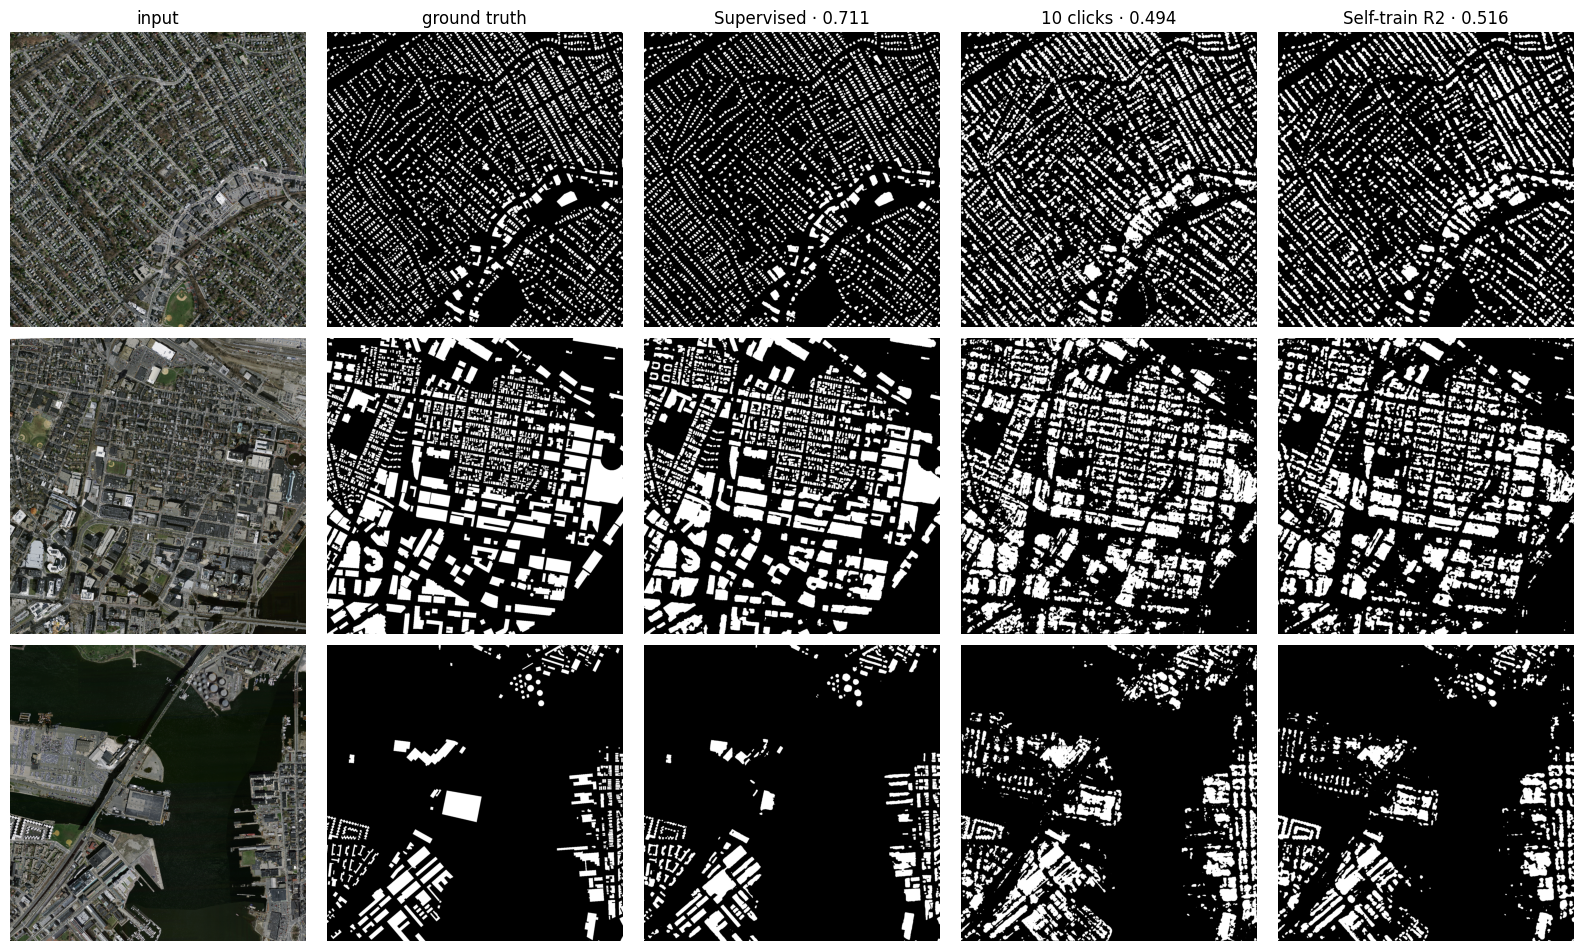

In [37]:
@torch.no_grad()
def predict(model, t):
    x = TF.normalize(store_test.images[t].float().div(255.0),
                     IMAGENET_MEAN, IMAGENET_STD).to(DEVICE)
    return (windowed_infer(model, x) > 0.5).cpu()

def load_ckpt(name, seed=0):
    m = get_model(pretrained=False)
    m.load_state_dict(torch.load(Path(CFG.run_dir) / f'{name}_seed{seed}' / 'best.pt',
                                  map_location=DEVICE))
    return m.eval()

sup, clk, r2 = load_ckpt('sup_bce_dice'), load_ckpt('pfce_n5'), load_ckpt('selftrain_r2')

show = [0, 3, 7]          # try different test-tile indices, pick visually nice ones
fig, axes = plt.subplots(len(show), 5, figsize=(16, 3.2 * len(show)))
for row, t in enumerate(show):
    axes[row, 0].imshow(store_test.images[t].permute(1, 2, 0).numpy())
    axes[row, 1].imshow(store_test.masks[t].numpy(), cmap='gray')
    for j, (m, ttl) in enumerate([(sup, 'Supervised · 0.711'),
                                  (clk, '10 clicks · 0.494'),
                                  (r2,  'Self-train R2 · 0.516')]):
        axes[row, 2 + j].imshow(predict(m, t).numpy(), cmap='gray')
        if row == 0: axes[row, 2 + j].set_title(ttl)
    if row == 0: axes[row, 0].set_title('input'); axes[row, 1].set_title('ground truth')
for ax in axes.flat: ax.axis('off')
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(Path(CFG.run_dir) / f'final_qualitative.{ext}', dpi=300, bbox_inches='tight')
plt.show()